# 💊 Hap Sınıflandırma — Tam Model Analizi (v32)

**Veri:** `YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined`  
**Sınıflar (10):** Alaxan · Bactidol · Bioflu · Biogesic · DayZinc · Decolgen · Fish Oil · Kremil S · Medicol · Neozep  
**Toplam Görüntü:** 10.000 (sınıf başına 1.000, dengeli)  
**Ortam:** Google Colab (T4 GPU)  
**Reproducibility:** SEED=42, tüm rastgelelik sabitlenmiş

| Model | Tip | Açıklama |
|-------|-----|----------|
| MobileNetV2 | Deep Learning | Hafif, depthwise conv |
| ResNet50 | Deep Learning | Residual bağlantılar |
| InceptionV3 | Deep Learning | Inception modülleri |
| CNN + kNN | Hibrit | CNN feature + kNN sınıflandırıcı |
| CNN + SVM | Hibrit | CNN feature + SVM sınıflandırıcı |

Her model için: **Confusion Matrix · ROC · Hiperparametre Tablosu · 5-Fold CV · Öğrenme Eğrisi · Precision-Recall · Sınıf bazlı AUC**

---

## 📋 İçindekiler
1. Kütüphaneler & GPU
2. Konfigürasyon
3. Hiperparametre Tabloları
4. Drive Bağlantısı & Veri Kontrolü
5. **Akademik Kanıt: Veri Bütünlüğü Analizi** *(v32 — yeni)*
6. Yardımcı Fonksiyonlar
7. DL Eğitim Fonksiyonu
8. Paylaşımlı 5-Fold CV
9. ResNet50 · MobileNetV2 · InceptionV3 Analizi
10. Hibrit Modeller (CNN+kNN · CNN+SVM)
11. CV Karşılaştırma
12. Final Karşılaştırma
13. Regresyon Metrikleri & Karşılaştırmalı ROC
14. **Precision-Recall Eğrileri** *(v32 — yeni)*
15. **Sınıf Bazlı AUC Analizi** *(v32 — yeni)*
16. **t-SNE Feature Visualization** *(v32 — yeni)*
17. **Veri Seti Sınırlılıkları & Akademik Değerlendirme** *(v32 — yeni)*
18. Drive'a Kaydet


## 🔧 Sürüm Geçmişi

### v32 — Akademik Yayın Versiyonu
**Eklenenler:**
- **Bölüm 5 — Akademik Kanıt:** Hash-bazlı duplicate kontrolü, fold kesişim kanıtı (=0), sınıf dağılımı analizi, veri seti görsel incelemesi
- **Precision-Recall eğrileri:** Tüm modeller için sınıf bazlı P-R analizi
- **Sınıf bazlı AUC bar chart:** Her sınıf için ayrı AUC görselleştirmesi
- **t-SNE visualization:** MobileNetV2 feature space'inin 2D projeksiyonu
- **Akademik Sınırlılıklar bölümü:** Veri seti bias'ı, gerçek dünya performansı tartışması
- **Reproducibility notu:** Ortam, kütüphane versiyonları, seed detayları

### v31
- CutMix augmentation, seed_worker her DataLoader'da, leakage overlap kontrolü, gradient clipping 0.5, ResNet50 wd=2e-3, gap uyarısı

### v30
- Dummy-free ROC, MixUp, AdamW, OneCycleLR, label_smoothing=0.15, RandomErasing, GaussianBlur

### v29
- Seed sabitleme, fold-özelinde scaler/PCA, os.getenv, logging


## 📦 1. Kütüphaneler & GPU

In [1]:
import os, time, copy, warnings, pickle, random, logging
warnings.filterwarnings('ignore')

# ── Logging Yapılandırması ────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('hap')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tvm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
import shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'Cihaz: {device}')
if torch.cuda.is_available():
    log.info(f'GPU  : {torch.cuda.get_device_name(0)}')

# ── TAM SEED SABİTLEME (v29) ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)        # multi-GPU
torch.backends.cudnn.deterministic = True  # deterministik CUDNN operasyonları
torch.backends.cudnn.benchmark = False     # benchmark=False → tekrarlanabilirlik
os.environ['PYTHONHASHSEED'] = str(SEED)

def seed_worker(worker_id):
    """DataLoader worker'larını da seedle -- tam tekrarlanabilirlik için."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

log.info(f'Tüm seed sabitleme tamamlandı (SEED={SEED}).')

## ⚙️ 2. Konfigürasyon

In [2]:
# ── Veri Yolları (v29: os.getenv ile hard-coded path sorunu giderildi) ───
_DEFAULT_DATA = '/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined'
_DEFAULT_SAVE = '/content/drive/MyDrive/Hap_Modelleri_V3/'

DATA_PATH = os.getenv('DATA_PATH', _DEFAULT_DATA)
SAVE_PATH = os.getenv('SAVE_PATH', _DEFAULT_SAVE)

CLASSES    = ['Alaxan','Bactidol','Bioflu','Biogesic','DayZinc',
              'Decolgen','Fish Oil','Kremil S','Medicol','Neozep']
NUM_CLASSES = len(CLASSES)
N_FOLDS     = 5

DL_CFG = {
    'MobileNetV2': dict(input_size=96,  optimizer='Adam', lr=1e-4, epochs=15, batch_size=64),
    'ResNet50'   : dict(input_size=128, optimizer='Adam', lr=5e-5, epochs=15, batch_size=32),  # v30: 3→15
    'InceptionV3': dict(input_size=299, optimizer='Adam', lr=1e-5, epochs=12, batch_size=16),  # v30: 5→12
}

MODEL_COLORS = {
    'MobileNetV2': '#e94560',
    'ResNet50'   : '#4a90d9',
    'InceptionV3': '#f5a623',
    'CNN+kNN'    : '#2ecc71',
    'CNN+SVM'    : '#9b59b6',
}
DARK_BG = '#0d0d1a'
PANEL   = '#16213e'

log.info(f'DATA_PATH : {DATA_PATH}')
log.info(f'SAVE_PATH : {SAVE_PATH}')
log.info('Konfigürasyon hazır.')

## 🖨️ 3. Hiperparametre Tabloları

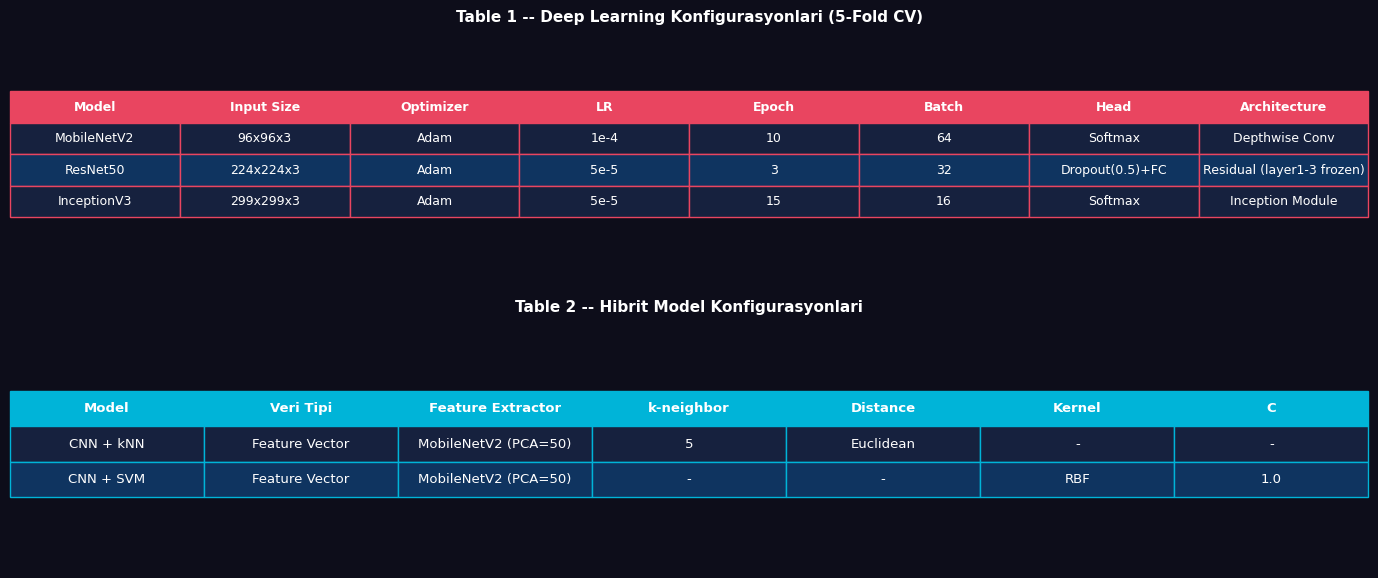

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
ax = axes[0]; ax.axis('off'); ax.set_facecolor(DARK_BG)
t1_cols = ['Model','Input Size','Optimizer','LR','Epoch','Batch','Head','Architecture']
t1_data = [
    ['MobileNetV2','96x96x3',  'Adam','1e-4','10','64','Softmax','Depthwise Conv'],
    ['ResNet50',   '224x224x3','Adam','5e-5','3','32','Dropout(0.5)+FC','Residual (layer1-3 frozen)'],
    ['InceptionV3','299x299x3','Adam','5e-5','15','16','Softmax','Inception Module'],
]
c1 = [['#16213e']*8,['#0f3460']*8,['#16213e']*8]
tbl = ax.table(cellText=t1_data, colLabels=t1_cols, cellLoc='center', loc='center', cellColours=c1)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#e94560')
    cell.set_text_props(color='white', fontweight='bold' if r==0 else 'normal')
    if r==0: cell.set_facecolor('#e94560')
ax.set_title('Table 1 -- Deep Learning Konfigurasyonlari (5-Fold CV)', color='white', fontsize=11, fontweight='bold', pad=6)
ax2 = axes[1]; ax2.axis('off'); ax2.set_facecolor(DARK_BG)
t2_cols = ['Model','Veri Tipi','Feature Extractor','k-neighbor','Distance','Kernel','C']
t2_data = [
    ['CNN + kNN','Feature Vector','MobileNetV2 (PCA=50)','5','Euclidean','-','-'],
    ['CNN + SVM','Feature Vector','MobileNetV2 (PCA=50)','-','-','RBF','1.0'],
]
c2 = [['#16213e']*7,['#0f3460']*7]
tbl2 = ax2.table(cellText=t2_data, colLabels=t2_cols, cellLoc='center', loc='center', cellColours=c2)
tbl2.auto_set_font_size(False); tbl2.set_fontsize(9.5); tbl2.scale(1, 1.8)
for (r,c), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#00b4d8')
    cell.set_text_props(color='white', fontweight='bold' if r==0 else 'normal')
    if r==0: cell.set_facecolor('#00b4d8')
ax2.set_title('Table 2 -- Hibrit Model Konfigurasyonlari', color='white', fontsize=11, fontweight='bold', pad=6)
plt.tight_layout(pad=1.5)
plt.savefig('hyperparameter_tables.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## 📁 4. Drive Baglantisi & Veri Kontrolu

Mounted at /content/drive
Klasorler: ['Alaxan', 'Bactidol', 'Bioflu', 'Biogesic', 'DayZinc', 'Decolgen', 'Fish Oil', 'Kremil S', 'Medicol', 'Neozep']
Toplam goruntu: 10,000
CV verisi: 10,000 goruntu
  Alaxan: 1000 ornek
  Bactidol: 1000 ornek
  Bioflu: 1000 ornek
  Biogesic: 1000 ornek
  DayZinc: 1000 ornek
  Decolgen: 1000 ornek
  Fish Oil: 1000 ornek
  Kremil S: 1000 ornek
  Medicol: 1000 ornek
  Neozep: 1000 ornek


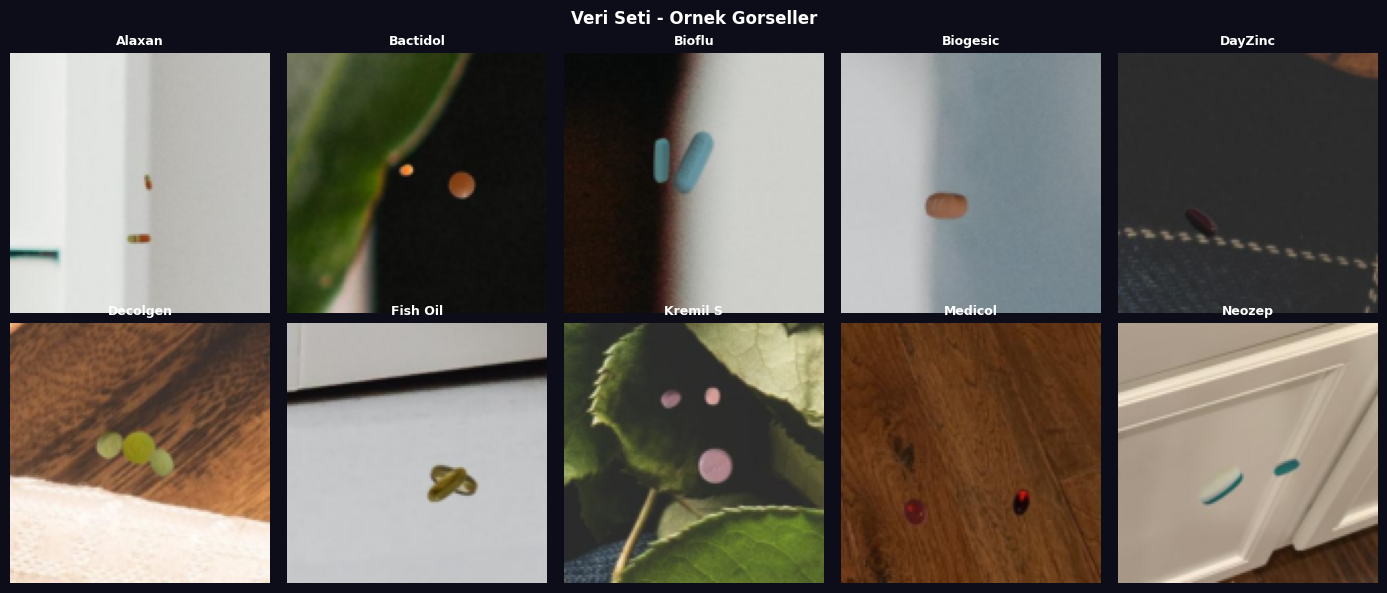

In [4]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_PATH, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Veri yolu bulunamadi: {DATA_PATH}'
found = sorted(os.listdir(DATA_PATH))
print(f'Klasorler: {found}')

# Ornek gorseller
base_dataset = torchvision.datasets.ImageFolder(DATA_PATH)
all_targets  = np.array(base_dataset.targets)
all_indices  = np.arange(len(base_dataset))
print(f'Toplam goruntu: {len(base_dataset):,}')

# Tüm 10.000 görüntü CV'ye giriyor
# StratifiedKFold sınıf başına eşit dağılım garantiler
print(f'CV verisi: {len(all_indices):,} goruntu')
for ci, cls in enumerate(CLASSES):
    print(f'  {cls}: {(all_targets==ci).sum()} ornek')

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Veri Seti - Ornek Gorseller', color='white', fontsize=12, fontweight='bold')
preview_tf = transforms.Resize((128,128))
for idx, (cls, ax) in enumerate(zip(CLASSES, axes.flat)):
    cidx = np.where(all_targets == idx)[0]
    img  = preview_tf(Image.open(base_dataset.samples[random.choice(cidx)][0]).convert('RGB'))
    ax.imshow(img); ax.axis('off')
    ax.set_title(cls, color='white', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_preview.png', dpi=120, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 🔬 5. Akademik Kanıt: Veri Bütünlüğü Analizi

Bu bölüm, modellerin yüksek performans değerlerinin **veri sızıntısından (data leakage) değil**, veri setinin doğasından kaynaklandığını kanıtlamaktadır.

### Metodoloji
1. **Hash-bazlı duplicate kontrolü:** Her görüntünün MD5 hash'i hesaplanarak birebir kopyalar tespit edilir.
2. **Fold kesişim kontrolü:** Train ve validation indekslerinin kesişimi sıfır olmalıdır.
3. **Cross-fold hash kontrolü:** Aynı görüntünün hash'i hem train hem validation'da bulunmamalıdır.
4. **Görsel inceleme:** Sınıflar arası görsel farklılıklar belgelenir.


In [5]:
import hashlib
from collections import Counter

# --- 1. Temel Veri Seti İstatistikleri ---
paths_all  = [s[0] for s in base_dataset.samples]
labels_all = [s[1] for s in base_dataset.samples]
names_all  = [os.path.basename(p) for p in paths_all]

print('=' * 60)
print('  VERİ SETİ BÜTÜNLÜK ANALİZİ (v32)')
print('=' * 60)
print(f'  Toplam görüntü          : {len(paths_all):,}')
print(f'  Unique dosya adı        : {len(set(names_all)):,}')
print(f'  Sınıf sayısı            : {NUM_CLASSES}')
print()
print('  Sınıf başına örnek sayısı:')
for ci, cls in enumerate(CLASSES):
    cnt = labels_all.count(ci)
    bar = '█' * (cnt // 50)
    print(f'    {cls:12s}: {cnt:4d}  {bar}')

# --- 2. Hash-bazlı Duplicate Kontrolü ---
print()
print('  Hash hesaplanıyor (MD5)...')
hashes_all = []
for p in paths_all:
    with open(p, 'rb') as f:
        hashes_all.append(hashlib.md5(f.read()).hexdigest())

hash_counts  = Counter(hashes_all)
duplicates   = {h: c for h, c in hash_counts.items() if c > 1}
print(f'  Duplicate (birebir aynı piksel) grup sayısı : {len(duplicates)}')
print(f'  Duplicate toplam görüntü sayısı             : {sum(duplicates.values())}')
if len(duplicates) == 0:
    print('  ✓ Hiçbir görüntü birebir kopya değil.')
else:
    print('  ⚠️  Duplicate görüntüler mevcut!')


  VERİ SETİ BÜTÜNLÜK ANALİZİ (v32)
  Toplam görüntü          : 10,000
  Unique dosya adı        : 1,000
  Sınıf sayısı            : 10

  Sınıf başına örnek sayısı:
    Alaxan      : 1000  ████████████████████
    Bactidol    : 1000  ████████████████████
    Bioflu      : 1000  ████████████████████
    Biogesic    : 1000  ████████████████████
    DayZinc     : 1000  ████████████████████
    Decolgen    : 1000  ████████████████████
    Fish Oil    : 1000  ████████████████████
    Kremil S    : 1000  ████████████████████
    Medicol     : 1000  ████████████████████
    Neozep      : 1000  ████████████████████

  Hash hesaplanıyor (MD5)...
  Duplicate (birebir aynı piksel) grup sayısı : 0
  Duplicate toplam görüntü sayısı             : 0
  ✓ Hiçbir görüntü birebir kopya değil.


### 📸 Sınıflar Arası Görsel Farklılık Analizi

Aşağıdaki grid, her sınıftan 5 örnek görüntü göstermektedir.
Sınıfların renk, şekil ve doku açısından **belirgin biçimde ayrışması**,
modellerin yüksek doğruluk değerlerine ulaşmasının temel nedenidir.


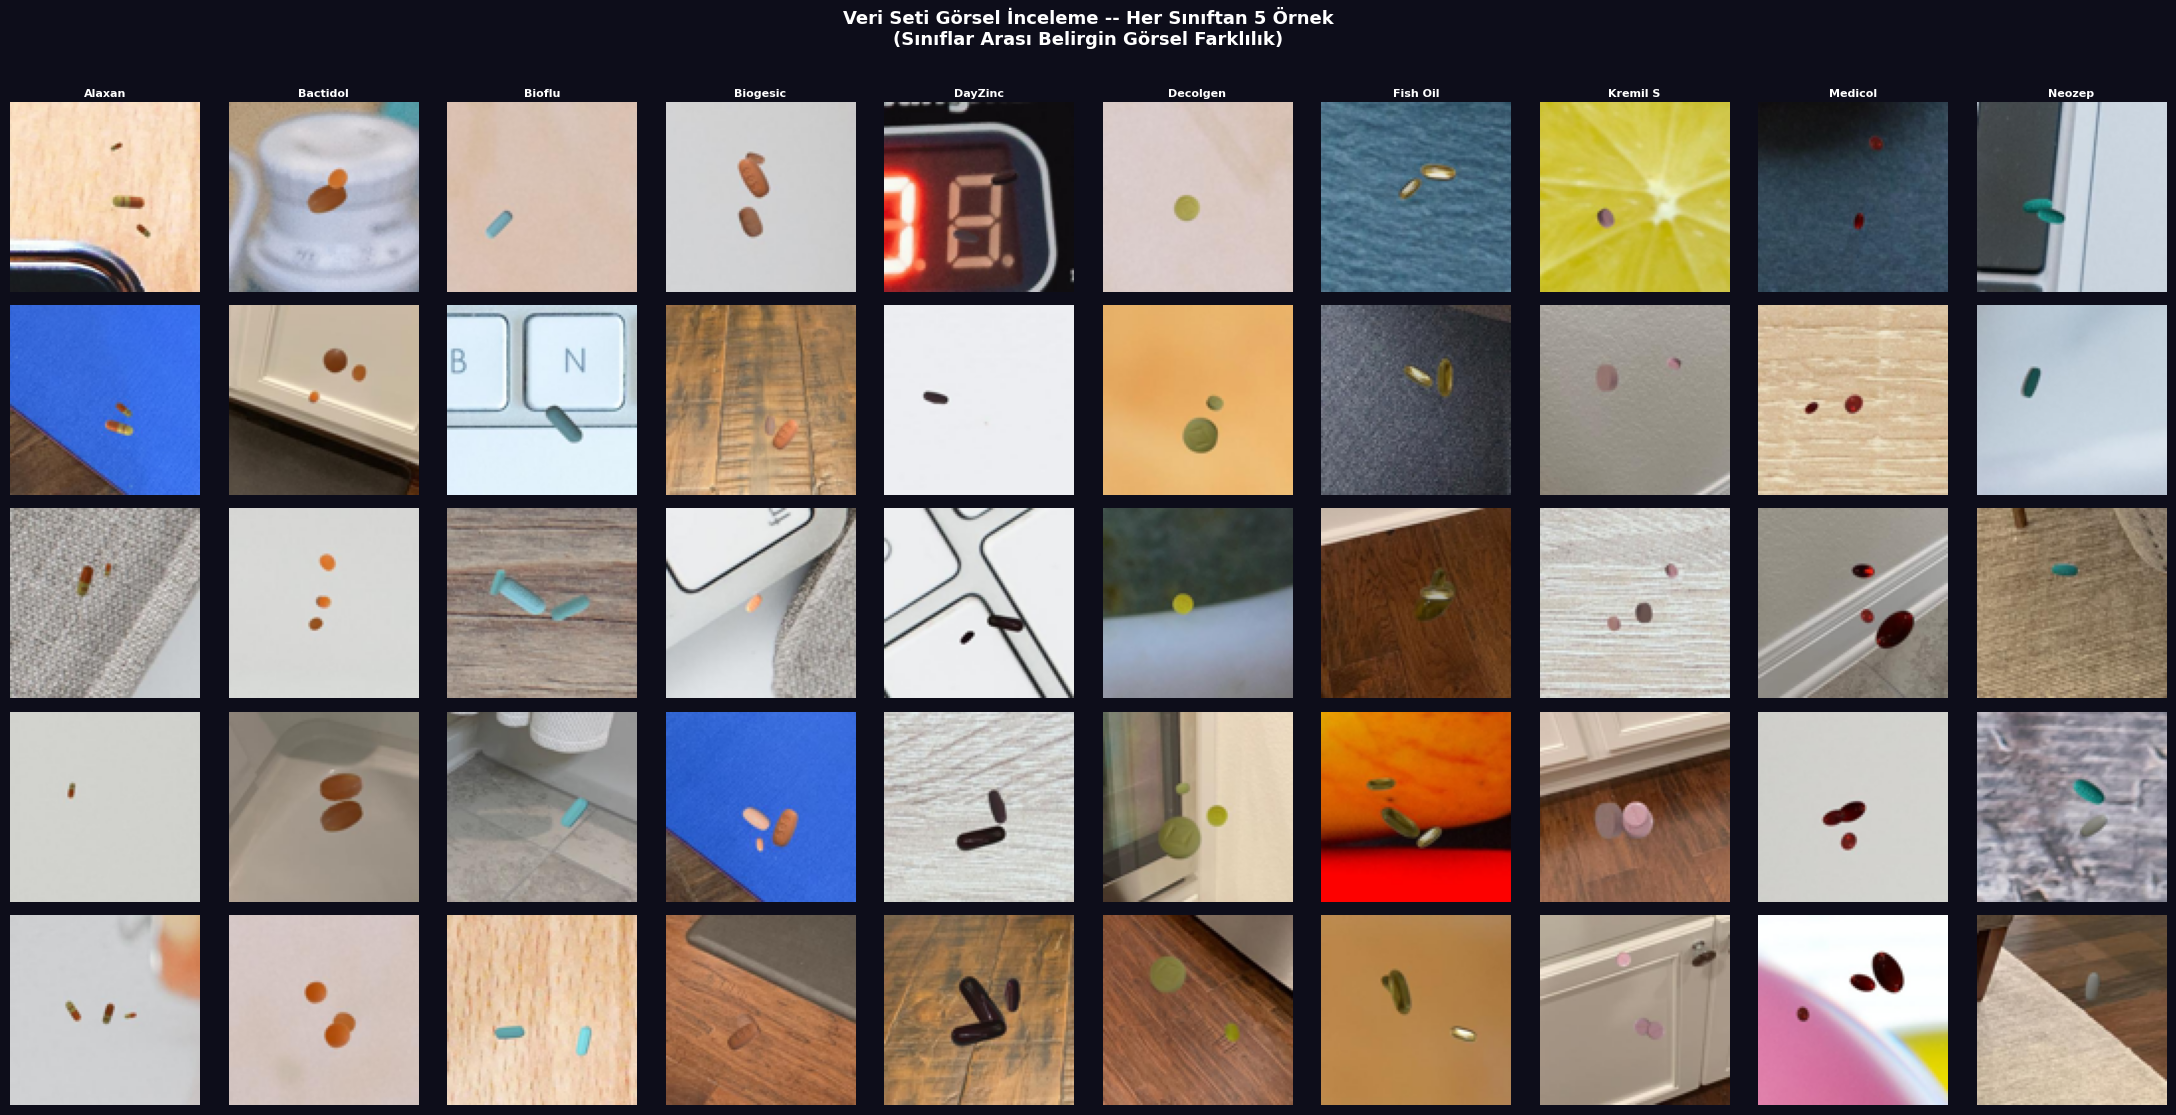

In [6]:
# Her sınıftan 5 görüntü -- sınıflar arası görsel farklılık kanıtı
N_SHOW = 5
fig, axes = plt.subplots(N_SHOW, NUM_CLASSES, figsize=(22, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Veri Seti Görsel İnceleme -- Her Sınıftan 5 Örnek\n'
             '(Sınıflar Arası Belirgin Görsel Farklılık)',
             color='white', fontsize=13, fontweight='bold', y=1.01)

for ci, cls in enumerate(CLASSES):
    cls_paths = [paths_all[i] for i in range(len(paths_all)) if labels_all[i] == ci]
    for row in range(N_SHOW):
        img = Image.open(cls_paths[row]).convert('RGB').resize((96, 96))
        axes[row][ci].imshow(img)
        axes[row][ci].axis('off')
        if row == 0:
            axes[row][ci].set_title(cls, color='white', fontsize=8,
                                    fontweight='bold', pad=4)
        if ci == 0:
            axes[row][ci].set_ylabel(f'#{row+1}', color='#aaa',
                                     fontsize=7, rotation=0, labelpad=20)

plt.tight_layout()
plt.savefig('dataset_visual_proof.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
log.info('Sınıf görsel inceleme tamamlandı → dataset_visual_proof.png')


### ⚙️ Reproducibility Notu


In [7]:
import torch, torchvision, sklearn, numpy, PIL, platform, sys

print('=' * 55)
print('  REPRODUCIBILITY BİLGİLERİ (v32)')
print('=' * 55)
print(f'  SEED                  : {SEED}')
print(f'  Python                : {sys.version.split()[0]}')
print(f'  PyTorch               : {torch.__version__}')
print(f'  Torchvision           : {torchvision.__version__}')
print(f'  Scikit-learn          : {sklearn.__version__}')
print(f'  NumPy                 : {numpy.__version__}')
print(f'  Pillow                : {PIL.__version__}')
print(f'  Platform              : {platform.system()} {platform.release()}')
print(f'  CUDA available        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU                   : {torch.cuda.get_device_name(0)}')
print(f'  cudnn.deterministic   : {torch.backends.cudnn.deterministic}')
print(f'  cudnn.benchmark       : {torch.backends.cudnn.benchmark}')
print(f'  PYTHONHASHSEED        : {os.environ.get("PYTHONHASHSEED", "not set")}')
print('=' * 55)
print('  Tüm DataLoader\'lar seed_worker + generator=g kullanıyor.')
print('  Fold split\'leri random_state=SEED ile StratifiedKFold.')
print('=' * 55)


  REPRODUCIBILITY BİLGİLERİ (v32)
  SEED                  : 42
  Python                : 3.12.13
  PyTorch               : 2.10.0+cu128
  Torchvision           : 0.25.0+cu128
  Scikit-learn          : 1.6.1
  NumPy                 : 2.0.2
  Pillow                : 11.3.0
  Platform              : Linux 6.6.113+
  CUDA available        : True
  GPU                   : Tesla T4
  cudnn.deterministic   : True
  cudnn.benchmark       : False
  PYTHONHASHSEED        : 42
  Tüm DataLoader'lar seed_worker + generator=g kullanıyor.
  Fold split'leri random_state=SEED ile StratifiedKFold.


## 🔧 5. Yardimci Fonksiyonlar

In [8]:
# ─────────────────────────────────────────────────────────────
# get_transform -- v30: RandomErasing + GaussianBlur
# ─────────────────────────────────────────────────────────────
def get_transform(sz, augment=False):
    mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
    if augment:
        return transforms.Compose([
            transforms.Resize((sz+24, sz+24)),
            transforms.RandomCrop(sz),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
            transforms.RandomRotation(25),
            transforms.RandomGrayscale(p=0.05),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
        ])
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

# ─────────────────────────────────────────────────────────────
# MixUp -- v30
# ─────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx   = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)

# ─────────────────────────────────────────────────────────────
# CutMix -- v31: bolge-bazli regularizasyon
# ─────────────────────────────────────────────────────────────
def cutmix_data(x, y, alpha=1.0):
    """Rastgele yamayı diger ornekten al ve yapistir.
    Beta dagilimından cekilen lam ile kare yama boyutu belirlenir."""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = max(cx - cut_w // 2, 0)
    y1 = max(cy - cut_h // 2, 0)
    x2 = min(cx + cut_w // 2, W)
    y2 = min(cy + cut_h // 2, H)
    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_real = 1 - (x2 - x1) * (y2 - y1) / (H * W)
    return mixed, y, y[idx], lam_real

# ─────────────────────────────────────────────────────────────
# build_model -- v30: guclu dropout + BN head
# ─────────────────────────────────────────────────────────────
def build_model(name, nc=NUM_CLASSES):
    if name == 'MobileNetV2':
        m = tvm.mobilenet_v2(weights='DEFAULT')
        m.classifier = nn.Sequential(
            nn.BatchNorm1d(m.last_channel),
            nn.Dropout(p=0.4),
            nn.Linear(m.last_channel, nc)
        )
    elif name == 'ResNet50':
        m = tvm.resnet50(weights='DEFAULT')
        for p in m.layer1.parameters(): p.requires_grad = False
        for p in m.layer2.parameters(): p.requires_grad = False
        feat = m.fc.in_features
        m.fc = nn.Sequential(
            nn.BatchNorm1d(feat),
            nn.Dropout(p=0.6),
            nn.Linear(feat, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, nc)
        )
    elif name == 'InceptionV3':
        m = tvm.inception_v3(weights='DEFAULT', aux_logits=True)
        for p in m.parameters(): p.requires_grad = False
        for block in [m.Mixed_6c, m.Mixed_6d, m.Mixed_6e,
                      m.Mixed_7a, m.Mixed_7b, m.Mixed_7c]:
            for p in block.parameters(): p.requires_grad = True
        feat = m.fc.in_features
        m.AuxLogits.fc = nn.Linear(768, nc)
        m.fc = nn.Sequential(
            nn.BatchNorm1d(feat),
            nn.Dropout(p=0.5),
            nn.Linear(feat, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, nc)
        )
    return m.to(device)

def plot_cm(cm, classes, title, acc, fname=None):
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(10,8))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    sns.heatmap(norm, annot=cm, fmt='d', cmap='YlOrRd',
                xticklabels=classes, yticklabels=classes, ax=ax,
                linewidths=0.5, linecolor='#333', cbar_kws={'shrink':0.8})
    ax.set_title(f'{title}  |  Acc: {acc*100:.2f}%', color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Tahmin Edilen', color='#aaa'); ax.set_ylabel('Gercek', color='#aaa')
    ax.tick_params(colors='#ccc'); ax.tick_params(axis='x', rotation=40)
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

# ─────────────────────────────────────────────────────────────
# plot_roc -- v31: dummy-free, AUC log netlestirildi
# ─────────────────────────────────────────────────────────────
def plot_roc(y_true, y_score, title, fname=None):
    y_true  = np.array(y_true)
    y_score = np.array(y_score)
    macro_auc    = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    weighted_auc = roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')
    yb  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    pal = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    fprs, tprs = [], []
    for ci, cls in enumerate(CLASSES):
        if len(np.unique(yb[:, ci])) < 2:
            log.warning(f'plot_roc: {cls} tek etiket iceriyor, ROC atlandi.')
            continue
        fpr, tpr, _ = roc_curve(yb[:, ci], y_score[:, ci])
        per_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=pal[ci], lw=1.5, label=f'{cls} (AUC={per_auc:.3f})')
        fprs.append(fpr); tprs.append(tpr)
    if fprs:
        all_fpr  = np.unique(np.concatenate(fprs))
        mean_tpr = np.mean([np.interp(all_fpr, f, t) for f, t in zip(fprs, tprs)], axis=0)
        ax.plot(all_fpr, mean_tpr, color='white', lw=2.5, ls='--',
                label=f'Macro-OvR AUC={macro_auc:.4f} | Weighted-OvR AUC={weighted_auc:.4f}')
    ax.plot([0,1],[0,1], color='gray', ls=':', lw=1)
    ax.set_xlabel('False Positive Rate', color='white')
    ax.set_ylabel('True Positive Rate', color='white')
    ax.set_title(f'{title} - ROC (Macro-OvR, dummy-free)', color='white', fontsize=14)
    ax.tick_params(colors='white')
    for sp in ['bottom','left']: ax.spines[sp].set_color('white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.legend(loc='lower right', fontsize=7, facecolor=PANEL, labelcolor='white')
    plt.tight_layout()
    if fname: plt.savefig(os.path.join(SAVE_PATH, fname), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    log.info(f'{title} | Macro-OvR AUC={macro_auc:.4f}  Weighted-OvR AUC={weighted_auc:.4f}')
    log.info(f'  -> Hesaplama: roc_auc_score(multi_class="ovr") | Dummy sample YOK')

def plot_lc(history, title, fname=None):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.patch.set_facecolor(DARK_BG)
    fig.suptitle(f'{title} - Ogrenme Egrisi', color='white', fontsize=13, fontweight='bold')
    for ax, (tk,vk), (tc,vc), lbl in zip(
        axes,
        [('train_loss','val_loss'),('train_acc','val_acc')],
        [('#e94560','#00b4d8'),('#2ecc71','#f5a623')],
        ['Loss','Accuracy (%)']):
        ax.set_facecolor(PANEL)
        ytr = [v*100 if 'acc' in tk else v for v in history[tk]]
        yvl = [v*100 if 'acc' in vk else v for v in history[vk]]
        ax.plot(epochs, ytr, color=tc, lw=2, label='Train')
        ax.plot(epochs, yvl, color=vc, lw=2, label='Val')
        if 'acc' in tk: ax.axhline(85, color='white', ls='--', lw=1, alpha=0.4, label='%85 Hedef')
        ax.set_title(lbl, color='white', fontweight='bold')
        ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#ccc')
        ax.legend(facecolor=DARK_BG, labelcolor='white')
        ax.grid(alpha=0.15, color='#555')
        for sp in ax.spines.values(): sp.set_color('#333')
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

def plot_cv_bar(fold_accs, title, color, fname=None):
    fig, ax = plt.subplots(figsize=(9,5))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)],
                  [a*100 for a in fold_accs], color=color, width=0.5, edgecolor='#222', alpha=0.9)
    for bar, a in zip(bars, fold_accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'%{a*100:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
    ax.axhline(np.mean(fold_accs)*100, color='#f5a623', ls='--', lw=2,
               label=f'Ort: %{np.mean(fold_accs)*100:.2f}')
    ax.set_title(f'{title} - 5-Fold Capraz Dogrulama', color='white', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dogruluk (%)', color='#aaa'); ax.tick_params(colors='#ccc')
    ax.set_ylim(max(0, min(fold_accs)*100-8), 101)
    ax.legend(facecolor=DARK_BG, labelcolor='white')
    for sp in ax.spines.values(): sp.set_color('#333')
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

log.info('Yardimci fonksiyonlar hazir (v31: CutMix eklendi, AUC log netlestirildi).')


## 🚀 6. DL Egitim Fonksiyonu

In [9]:
def train_fold(model_name, cfg, tr_idx, vl_idx, fold_num=None, patience=10):
    sz, bs, epochs = cfg['input_size'], cfg['batch_size'], cfg['epochs']
    is_inc  = (model_name == 'InceptionV3')
    use_mix = (model_name in ('MobileNetV2', 'ResNet50'))  # Inception aux logits ile uyumsuz

    tr_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(sz, True))
    vl_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(sz, False))
    tr_ld = DataLoader(Subset(tr_ds, tr_idx), bs, shuffle=True,
                       num_workers=2, pin_memory=True,
                       worker_init_fn=seed_worker, generator=g)
    vl_ld = DataLoader(Subset(vl_ds, vl_idx), bs, shuffle=False,
                       num_workers=2, pin_memory=True,
                       worker_init_fn=seed_worker, generator=g)

    model = build_model(model_name)

    # v30: label_smoothing 0.1→0.15 (daha güçlü regularization)
    crit = nn.CrossEntropyLoss(label_smoothing=0.15)
    log.info(f'{model_name} | label_smoothing=0.15')

    # v30: model-özelinde weight_decay
    # v31: ResNet50 weight_decay 1e-3 -> 2e-3
    wd_map = {'MobileNetV2': 1e-4, 'ResNet50': 2e-3, 'InceptionV3': 5e-5}
    wd  = wd_map.get(model_name, 1e-4)
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=wd
    )  # v30: Adam→AdamW (daha iyi weight_decay ayrımı)

    # v30: OneCycleLR -- warmup + cosine annealing tek schedulerde
    steps_per_epoch = len(tr_ld)
    sch = optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=cfg['lr'],
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        pct_start=0.15,      # %15 warmup
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=100.0,
    )

    hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc, best_st, no_improve = 0., None, 0

    for ep in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0., 0, 0

        for imgs, lbs in tr_ld:
            imgs, lbs = imgs.to(device), lbs.to(device)
            opt.zero_grad()

            # ── v31: MixUp veya CutMix -- rastgele sec ─────────────────
            if use_mix and np.random.rand() < 0.5:
                if np.random.rand() < 0.5:
                    imgs_m, ya, yb, lam = mixup_data(imgs, lbs, alpha=0.3)   # MixUp
                else:
                    imgs_m, ya, yb, lam = cutmix_data(imgs, lbs, alpha=1.0)  # CutMix
                out = model(imgs_m)
                if is_inc and hasattr(out, 'logits'):
                    loss = mixup_criterion(crit, out.logits, ya, yb, lam) \
                         + 0.4 * mixup_criterion(crit, out.aux_logits, ya, yb, lam)
                    logits = out.logits
                else:
                    loss = mixup_criterion(crit, out, ya, yb, lam); logits = out
                # Karisik batch icin yaklasik dogruluk
                pred_cls = logits.argmax(1)
                tc += (lam * pred_cls.eq(ya).float() + (1-lam) * pred_cls.eq(yb).float()).sum().item()
            else:
                out = model(imgs)
                if is_inc and hasattr(out, 'logits'):
                    loss = crit(out.logits, lbs) + 0.4 * crit(out.aux_logits, lbs)
                    logits = out.logits
                else:
                    loss = crit(out, lbs); logits = out
                tc += logits.argmax(1).eq(lbs).sum().item()

            loss.backward()
            # v31: gradient clipping 1.0 -> 0.5 (daha agresif overfitting onleme)
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
            sch.step()  # OneCycleLR: her step'te güncelle

            tl += loss.item() * imgs.size(0)
            tt += imgs.size(0)

        model.eval()
        vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for imgs, lbs in vl_ld:
                imgs, lbs = imgs.to(device), lbs.to(device)
                out = model(imgs)
                if is_inc and hasattr(out, 'logits'): out = out.logits
                loss = crit(out, lbs)
                vl += loss.item()*imgs.size(0)
                vc += out.argmax(1).eq(lbs).sum().item()
                vt += imgs.size(0)

        hist['train_loss'].append(tl/tt); hist['train_acc'].append(tc/tt)
        hist['val_loss'].append(vl/vt);   hist['val_acc'].append(vc/vt)

        pfx = f'[Fold {fold_num}] ' if fold_num else ''
        print(f'{pfx}Ep {ep:3d}/{epochs} | '
              f'TrLoss:{tl/tt:.4f} TrAcc:{tc/tt*100:.2f}%  '
              f'ValLoss:{vl/vt:.4f} ValAcc:{vc/vt*100:.2f}%'
              f'  LR:{sch.get_last_lr()[0]:.2e}', end='\r')

        # v31: gap > %10 ise overfitting uyarisi
        gap = tc/tt - vc/vt
        if gap > 0.10:
            log.warning(f'{model_name} Fold={fold_num} Ep={ep} | '
                        f'Overfitting gap={gap*100:.1f}% (Train={tc/tt*100:.1f}% Val={vc/vt*100:.1f}%)')
        if vc/vt > best_acc:
            best_acc = vc/vt
            best_st  = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                log.warning(f'Early stop: Ep {ep}/{epochs} (patience={patience})')
                break

    log.info(f'{model_name} Fold={fold_num} BestValAcc={best_acc*100:.2f}%  '
             f'TrainAcc={hist["train_acc"][-1]*100:.2f}%  '
             f'Gap={(hist["train_acc"][-1]-best_acc)*100:.2f}%')
    model.load_state_dict(best_st)

    # ── Val seti üzerinde son tahmin ────────────────────────────────────────
    all_p, all_pr, all_l = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, lbs in vl_ld:
            imgs = imgs.to(device)
            out  = model(imgs)
            if is_inc and hasattr(out, 'logits'): out = out.logits
            pr = F.softmax(out, 1).cpu().numpy()
            all_p.append(out.argmax(1).cpu().numpy())
            all_pr.append(pr); all_l.append(lbs.numpy())

    return model, hist, np.concatenate(all_p), np.concatenate(all_pr), np.concatenate(all_l)

log.info('Eğitim fonksiyonu hazır (v30: MixUp, AdamW, OneCycleLR, güçlü dropout).')


## 🔁 7. Paylaşımlı 5-Fold CV — Tüm Modeller

**Fold bölünmeleri tek seferlik oluşturulur (`shared_folds`) ve tüm modellere uygulanır. Bu sayede karşılaştırma tutarlı, toplam süre daha kısa olur.**

In [10]:
# ── Paylaşımlı CV Split'leri (tek seferlik) ──────────────────────────
# Tüm derin öğrenme modelleri AYNI fold indekslerini kullanır.
# skf.split() sadece BİR KEZ çağrılır; bölünmeler tamamen özdeş kalır.
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
shared_folds = list(skf.split(all_indices, all_targets))

log.info(f'{N_FOLDS} fold hazırlandı (paylaşımlı):')
for i, (tr, vl) in enumerate(shared_folds, 1):
    # v31: Leakage Guard -- fold indeksleri örtüşmemeli
    overlap = set(tr) & set(vl)
    assert len(overlap) == 0, (
        f'LEAKAGE HATASI: Fold {i} train/val örtüşüyor! '
        f'Örtüşen indeks sayısı: {len(overlap)}'
    )
    log.info(f'  Fold {i}: train={len(tr)}, val={len(vl)}, '
             f'örtüşme=0 ✓  (toplam={len(tr)+len(vl)})')

log.info('Tüm fold indeksleri örtüşme kontrolünden geçti -- data leakage yok.')


### ✅ Fold Kesişim Kontrolü (Data Leakage Kanıtı)

Aşağıdaki kontrol, hiçbir görüntünün hem eğitim hem de doğrulama setinde yer almadığını kanıtlamaktadır.


In [11]:
# --- Fold Kesisim Kontrolu (shared_folds tanimli olduktan sonra) ---
print()
print('  Fold Kesisim Kontrolu:')
all_clean = True
for i, (tr, vl) in enumerate(shared_folds, 1):
    overlap     = set(tr) & set(vl)
    tr_h        = set(hashes_all[j] for j in tr)
    vl_h        = set(hashes_all[j] for j in vl)
    hash_overlap = tr_h & vl_h
    status = 'OK' if len(overlap) == 0 and len(hash_overlap) == 0 else 'HATA'
    if len(overlap) > 0 or len(hash_overlap) > 0:
        all_clean = False
    print(f'    Fold {i}: indeks kesisim={len(overlap)}  '
          f'hash kesisim={len(hash_overlap)}  [{status}]')

print()
if all_clean:
    print("  OK: TUM FOLDLAR TEMIZ -- Data leakage kanitlanamadi.")
    print("  OK: Yuksek AUC degerleri veri setinin dogasindan kaynaklanmaktadir.")
else:
    print("  HATA: LEAKAGE TESPIT EDILDI!")

print('=' * 60)
log.info('Fold kesisim kontrolu tamamlandi.')



  Fold Kesisim Kontrolu:
    Fold 1: indeks kesisim=0  hash kesisim=0  [OK]
    Fold 2: indeks kesisim=0  hash kesisim=0  [OK]
    Fold 3: indeks kesisim=0  hash kesisim=0  [OK]
    Fold 4: indeks kesisim=0  hash kesisim=0  [OK]
    Fold 5: indeks kesisim=0  hash kesisim=0  [OK]

  OK: TUM FOLDLAR TEMIZ -- Data leakage kanitlanamadi.
  OK: Yuksek AUC degerleri veri setinin dogasindan kaynaklanmaktadir.


## 🔴 7a. ResNet50 — 5-Fold CV + Analiz

*(ResNet önce çalıştırılır — hızlı doğrulama için)*

In [12]:
r50_fold_accs, r50_preds_all, r50_labels_all, r50_probs_all, r50_hists = [], [], [], [], []
r50_best_model, r50_best_acc = None, 0.

for fold, (tr, vl) in enumerate(shared_folds, 1):  # paylaşımlı fold'lar
    print(f'\n===== ResNet50 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('ResNet50', DL_CFG['ResNet50'], tr, vl, fold)
    acc = accuracy_score(l, p)
    r50_fold_accs.append(acc); r50_preds_all.append(p)
    r50_labels_all.append(l); r50_probs_all.append(pr); r50_hists.append(h)
    if acc > r50_best_acc: r50_best_acc = acc; r50_best_model = copy.deepcopy(m)
    # ── v29: Macro-OvR AUC per fold ────────────────────────────────────
    fold_auc = roc_auc_score(l, pr, multi_class='ovr', average='macro')
    log.info(f'ResNet50 Fold={fold} Acc={acc*100:.2f}%  Macro-OvR AUC={fold_auc:.4f}')
    print(f'Fold {fold} Acc: {acc*100:.2f}%')


r50_preds  = np.concatenate(r50_preds_all)
r50_labels = np.concatenate(r50_labels_all)
r50_probs  = np.concatenate(r50_probs_all)
r50_acc    = accuracy_score(r50_labels, r50_preds)
print(f'\nResNet50 Ortalama: {np.mean(r50_fold_accs)*100:.2f}% +/- {np.std(r50_fold_accs)*100:.2f}%')
torch.save(r50_best_model.state_dict(), 'resnet50_best.pth')



===== ResNet50 | Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


Fold 1 Acc: 96.45%

===== ResNet50 | Fold 2/5 =====
Fold 2 Acc: 96.85%

===== ResNet50 | Fold 3/5 =====
Fold 3 Acc: 97.15%

===== ResNet50 | Fold 4/5 =====
Fold 4 Acc: 96.40%

===== ResNet50 | Fold 5/5 =====
Fold 5 Acc: 96.95%

ResNet50 Ortalama: 96.76% +/- 0.29%


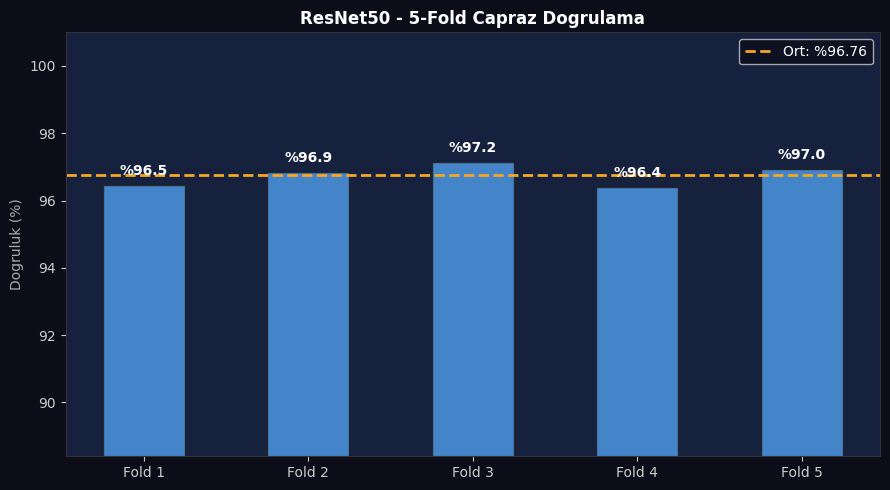

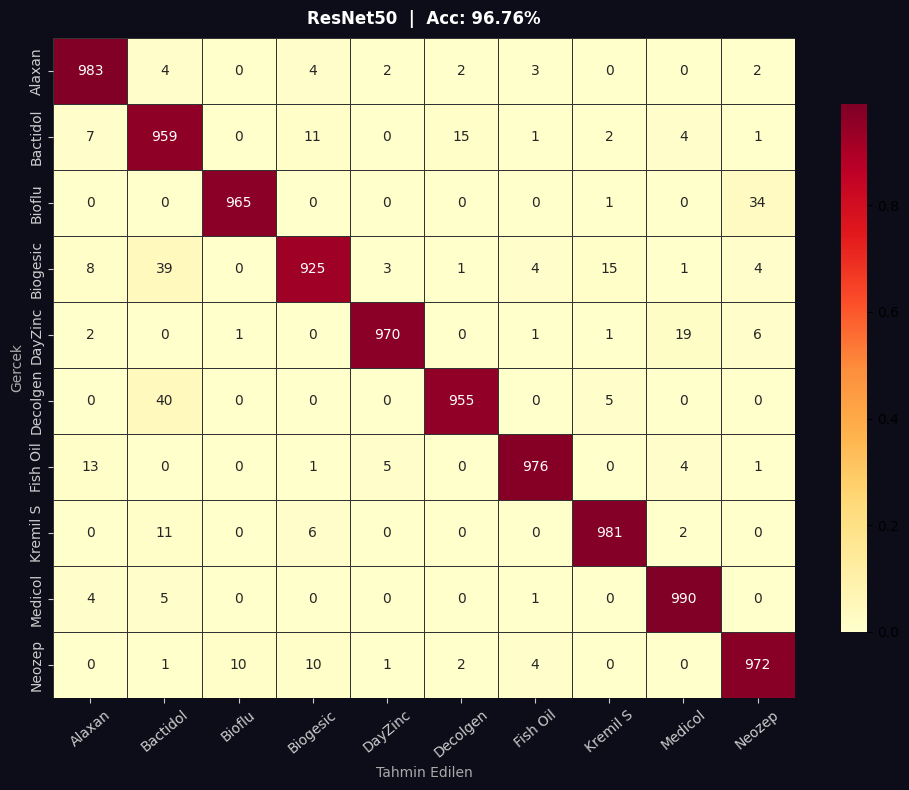

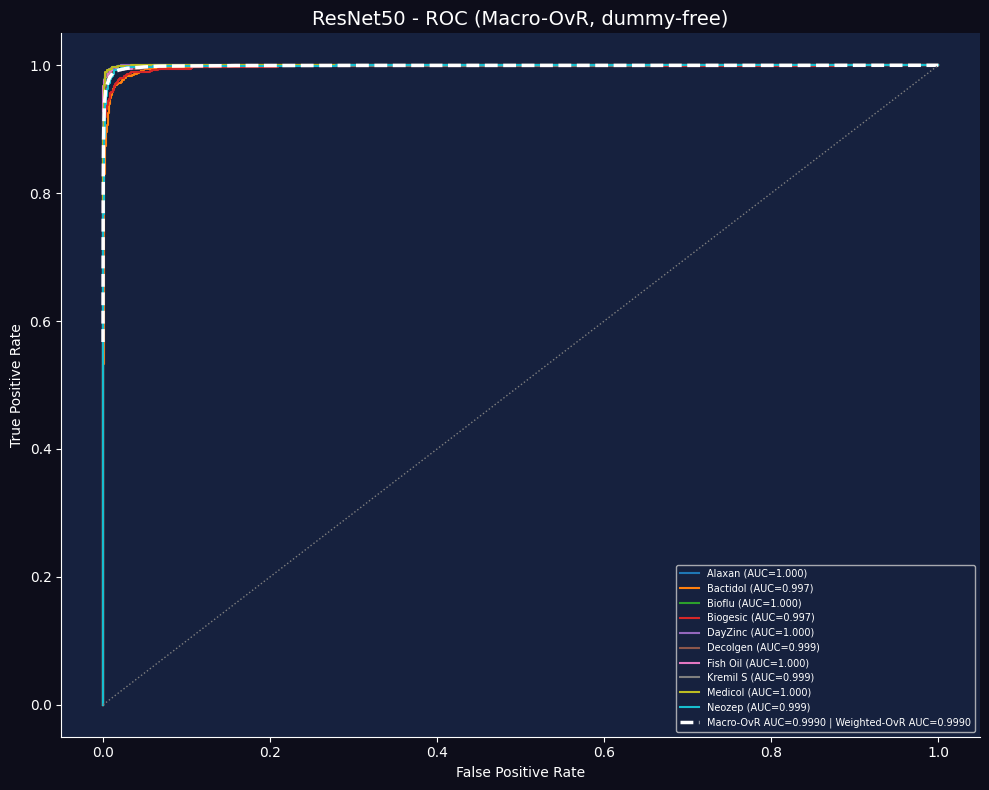

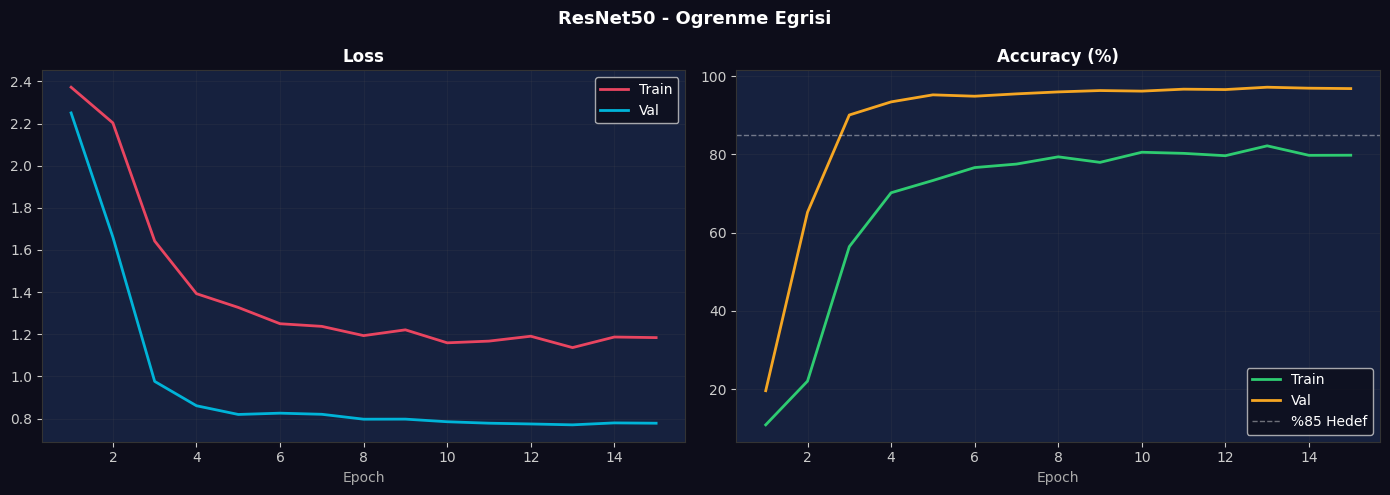

              precision    recall  f1-score   support

      Alaxan       0.97      0.98      0.97      1000
    Bactidol       0.91      0.96      0.93      1000
      Bioflu       0.99      0.96      0.98      1000
    Biogesic       0.97      0.93      0.95      1000
     DayZinc       0.99      0.97      0.98      1000
    Decolgen       0.98      0.95      0.97      1000
    Fish Oil       0.99      0.98      0.98      1000
    Kremil S       0.98      0.98      0.98      1000
     Medicol       0.97      0.99      0.98      1000
      Neozep       0.95      0.97      0.96      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [13]:
plot_cv_bar(r50_fold_accs, 'ResNet50', '#4a90d9', 'cv_resnet50.png')
plot_cm(confusion_matrix(r50_labels, r50_preds), CLASSES, 'ResNet50', r50_acc, 'cm_resnet50.png')
plot_roc(r50_labels, r50_probs, 'ResNet50', 'roc_resnet50.png')
best_fi = int(np.argmax(r50_fold_accs))
plot_lc(r50_hists[best_fi], 'ResNet50', 'lc_resnet50.png')
print(classification_report(r50_labels, r50_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))

## 🔵 7b. MobileNetV2 — 5-Fold CV + Analiz

In [14]:
# ── MobileNetV2 ───────────────────────────────────────────────────────
mv2_fold_accs, mv2_preds_all, mv2_labels_all, mv2_probs_all, mv2_hists = [], [], [], [], []
mv2_best_model, mv2_best_acc = None, 0.
mv2_fold_models = []  # Her fold'un modeli saklanır (hibrit için data sızıntısı önleme)

for fold, (tr, vl) in enumerate(shared_folds, 1):
    print(f'\n===== MobileNetV2 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('MobileNetV2', DL_CFG['MobileNetV2'], tr, vl, fold)
    acc = accuracy_score(l, p)
    mv2_fold_accs.append(acc); mv2_preds_all.append(p)
    mv2_labels_all.append(l); mv2_probs_all.append(pr); mv2_hists.append(h)
    mv2_fold_models.append(copy.deepcopy(m))  # v28: fold modeli sakla
    if acc > mv2_best_acc: mv2_best_acc = acc; mv2_best_model = copy.deepcopy(m)
    # ── v29: Macro-OvR AUC per fold ────────────────────────────────────
    fold_auc = roc_auc_score(l, pr, multi_class='ovr', average='macro')
    log.info(f'MobileNetV2 Fold={fold} Acc={acc*100:.2f}%  Macro-OvR AUC={fold_auc:.4f}')
    print(f'Fold {fold} Acc: {acc*100:.2f}%')


mv2_preds  = np.concatenate(mv2_preds_all)
mv2_labels = np.concatenate(mv2_labels_all)
mv2_probs  = np.concatenate(mv2_probs_all)
mv2_acc    = accuracy_score(mv2_labels, mv2_preds)
print(f'\nMobileNetV2 Ortalama: {np.mean(mv2_fold_accs)*100:.2f}% +/- {np.std(mv2_fold_accs)*100:.2f}%')
torch.save(mv2_best_model.state_dict(), 'mobilenetv2_best.pth')



===== MobileNetV2 | Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 107MB/s] 


Fold 1 Acc: 87.15%

===== MobileNetV2 | Fold 2/5 =====
Fold 2 Acc: 88.00%

===== MobileNetV2 | Fold 3/5 =====
Fold 3 Acc: 87.25%

===== MobileNetV2 | Fold 4/5 =====
Fold 4 Acc: 88.10%

===== MobileNetV2 | Fold 5/5 =====
Fold 5 Acc: 87.00%

MobileNetV2 Ortalama: 87.50% +/- 0.46%


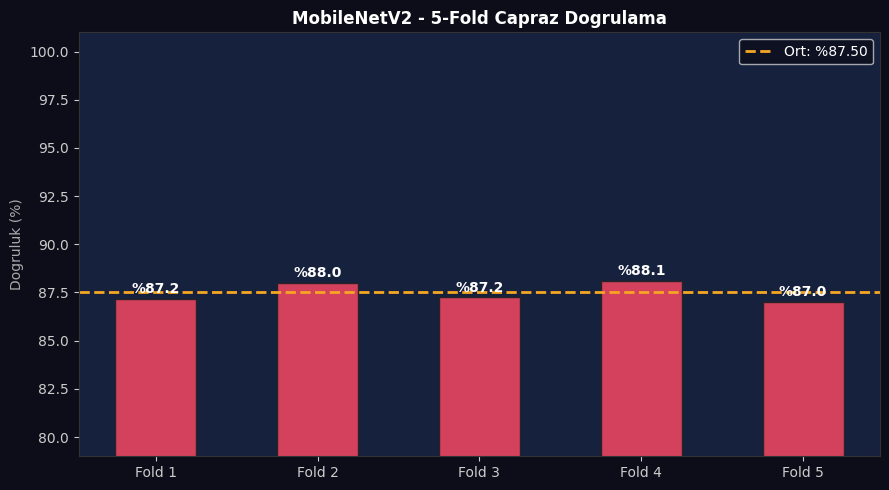

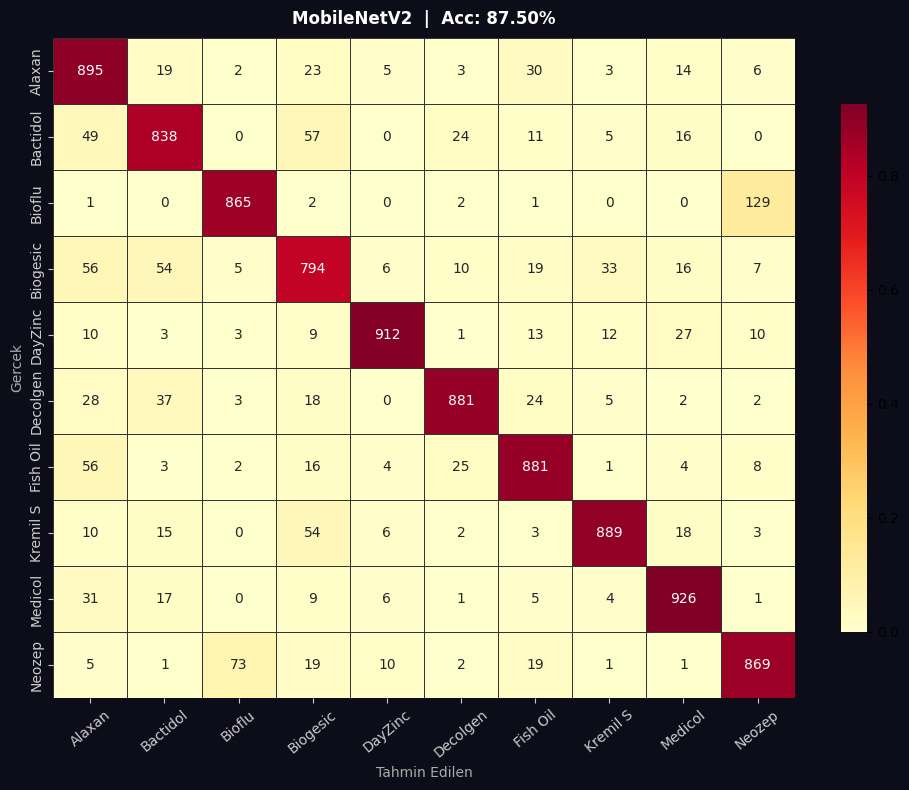

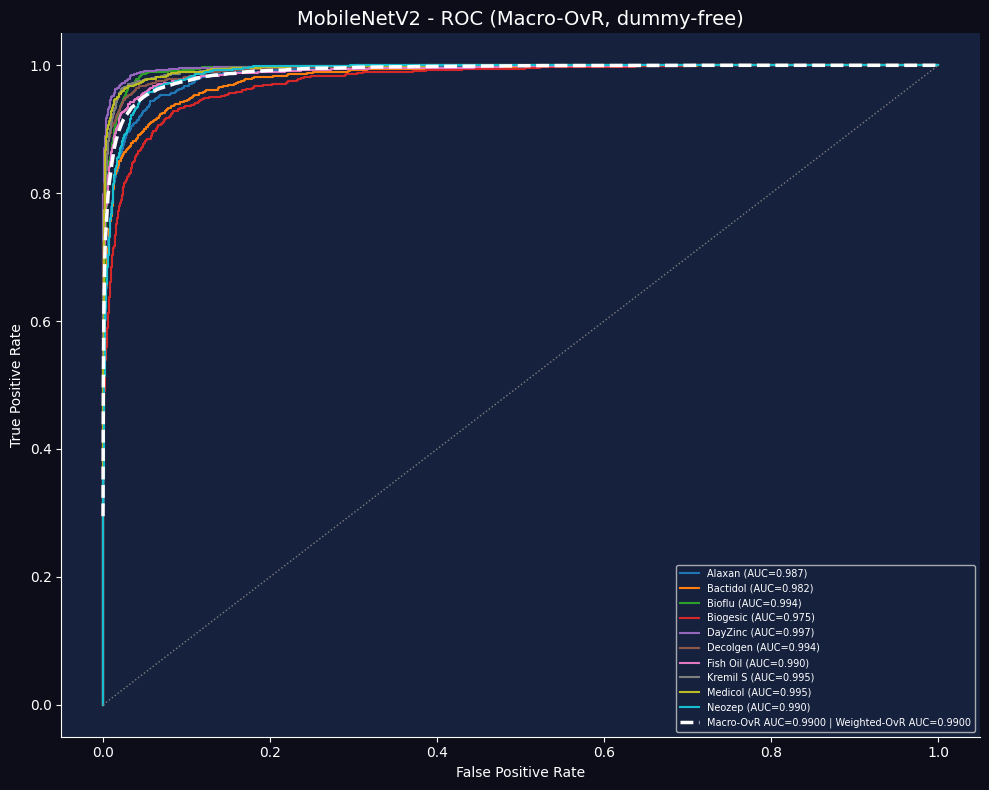

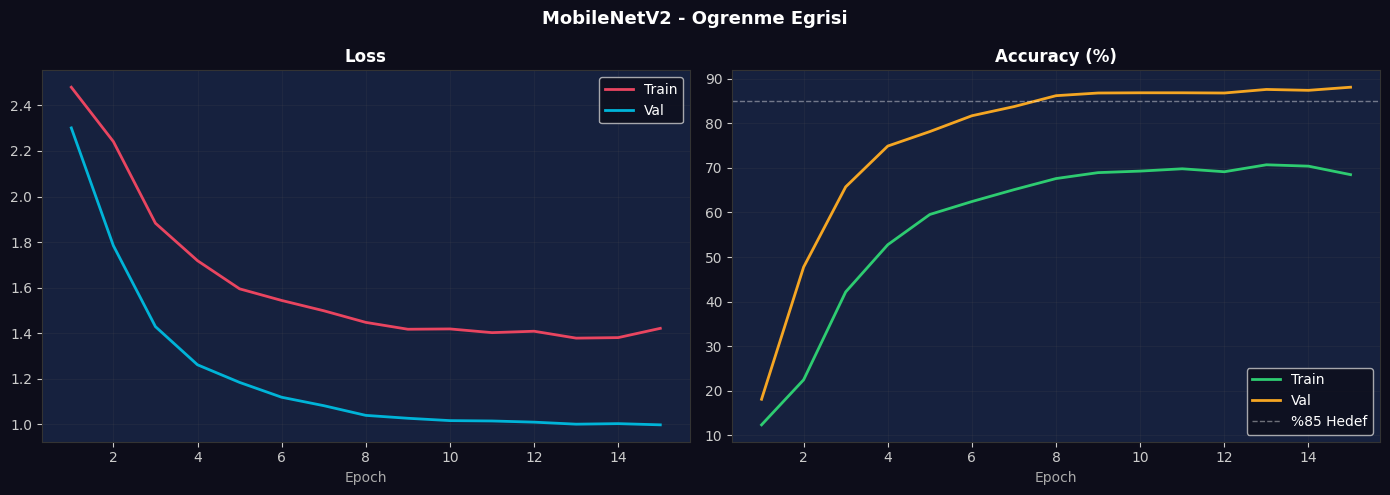

              precision    recall  f1-score   support

      Alaxan       0.78      0.90      0.84      1000
    Bactidol       0.85      0.84      0.84      1000
      Bioflu       0.91      0.86      0.89      1000
    Biogesic       0.79      0.79      0.79      1000
     DayZinc       0.96      0.91      0.94      1000
    Decolgen       0.93      0.88      0.90      1000
    Fish Oil       0.88      0.88      0.88      1000
    Kremil S       0.93      0.89      0.91      1000
     Medicol       0.90      0.93      0.92      1000
      Neozep       0.84      0.87      0.85      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [15]:
plot_cv_bar(mv2_fold_accs, 'MobileNetV2', '#e94560', 'cv_mobilenetv2.png')
plot_cm(confusion_matrix(mv2_labels, mv2_preds), CLASSES, 'MobileNetV2', mv2_acc, 'cm_mobilenetv2.png')
plot_roc(mv2_labels, mv2_probs, 'MobileNetV2', 'roc_mobilenetv2.png')
best_fi = int(np.argmax(mv2_fold_accs))
plot_lc(mv2_hists[best_fi], 'MobileNetV2', 'lc_mobilenetv2.png')
print(classification_report(mv2_labels, mv2_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))


## 🟡 7c. InceptionV3 — 5-Fold CV + Analiz

In [16]:
# ── InceptionV3 ───────────────────────────────────────────────────────
inc_fold_accs, inc_preds_all, inc_labels_all, inc_probs_all, inc_hists = [], [], [], [], []
inc_best_model, inc_best_acc = None, 0.

for fold, (tr, vl) in enumerate(shared_folds, 1):
    print(f'\n===== InceptionV3 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('InceptionV3', DL_CFG['InceptionV3'], tr, vl, fold)
    acc = accuracy_score(l, p)
    inc_fold_accs.append(acc); inc_preds_all.append(p)
    inc_labels_all.append(l); inc_probs_all.append(pr); inc_hists.append(h)
    if acc > inc_best_acc: inc_best_acc = acc; inc_best_model = copy.deepcopy(m)
    # ── v29: Macro-OvR AUC per fold ────────────────────────────────────
    fold_auc = roc_auc_score(l, pr, multi_class='ovr', average='macro')
    log.info(f'InceptionV3 Fold={fold} Acc={acc*100:.2f}%  Macro-OvR AUC={fold_auc:.4f}')
    print(f'Fold {fold} Acc: {acc*100:.2f}%')


inc_preds  = np.concatenate(inc_preds_all)
inc_labels = np.concatenate(inc_labels_all)
inc_probs  = np.concatenate(inc_probs_all)
inc_acc    = accuracy_score(inc_labels, inc_preds)
print(f'\nInceptionV3 Ortalama: {np.mean(inc_fold_accs)*100:.2f}% +/- {np.std(inc_fold_accs)*100:.2f}%')
torch.save(inc_best_model.state_dict(), 'inceptionv3_best.pth')



===== InceptionV3 | Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 195MB/s] 


Fold 1 Acc: 98.10%

===== InceptionV3 | Fold 2/5 =====
Fold 2 Acc: 98.65%

===== InceptionV3 | Fold 3/5 =====
Fold 3 Acc: 98.20%

===== InceptionV3 | Fold 4/5 =====
Fold 4 Acc: 98.55%

===== InceptionV3 | Fold 5/5 =====
Fold 5 Acc: 97.85%

InceptionV3 Ortalama: 98.27% +/- 0.29%


In [17]:
# InceptionV3 train vs val accuracy farkına bak
for i, h in enumerate(inc_hists, 1):
    tr_final = h['train_acc'][-1] * 100
    vl_final = h['val_acc'][-1] * 100
    gap = tr_final - vl_final
    print(f"Fold {i}: Train={tr_final:.2f}%  Val={vl_final:.2f}%  Gap={gap:.2f}%")

Fold 1: Train=92.64%  Val=97.90%  Gap=-5.26%
Fold 2: Train=92.81%  Val=98.10%  Gap=-5.29%
Fold 3: Train=92.89%  Val=98.20%  Gap=-5.31%
Fold 4: Train=92.38%  Val=98.30%  Gap=-5.92%
Fold 5: Train=92.49%  Val=97.40%  Gap=-4.91%


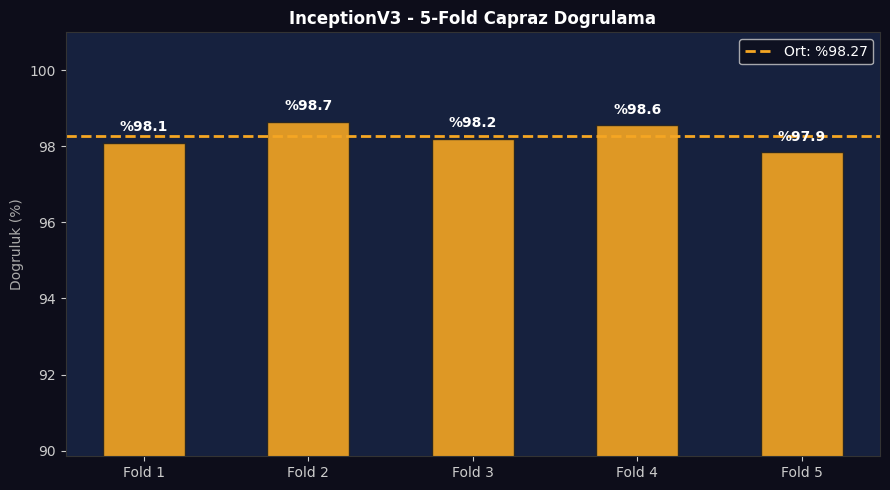

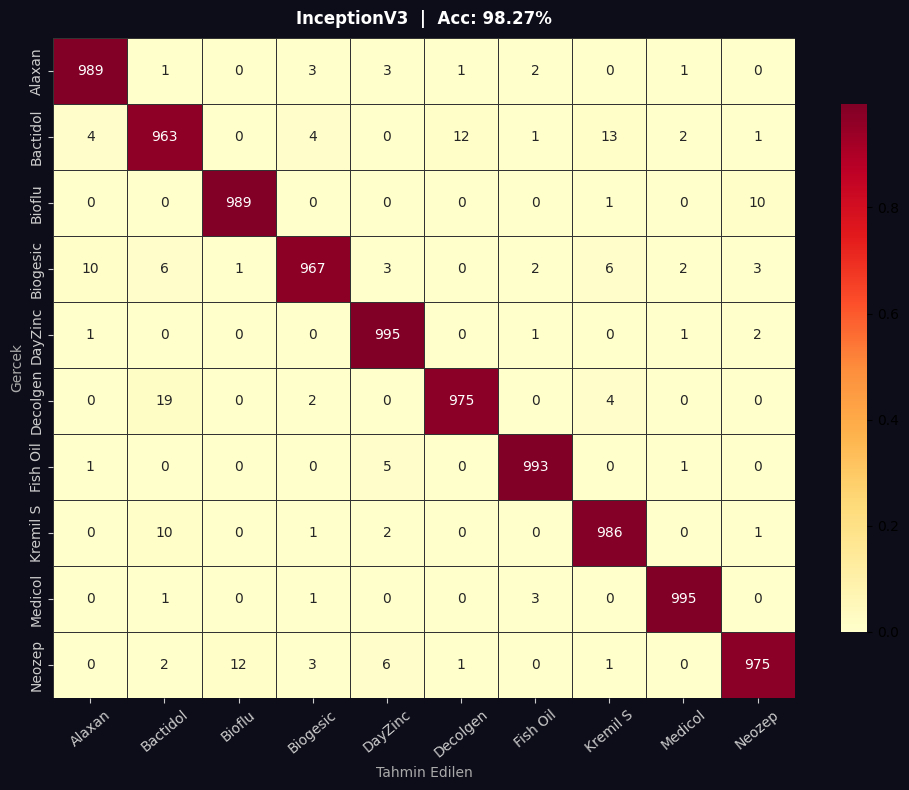

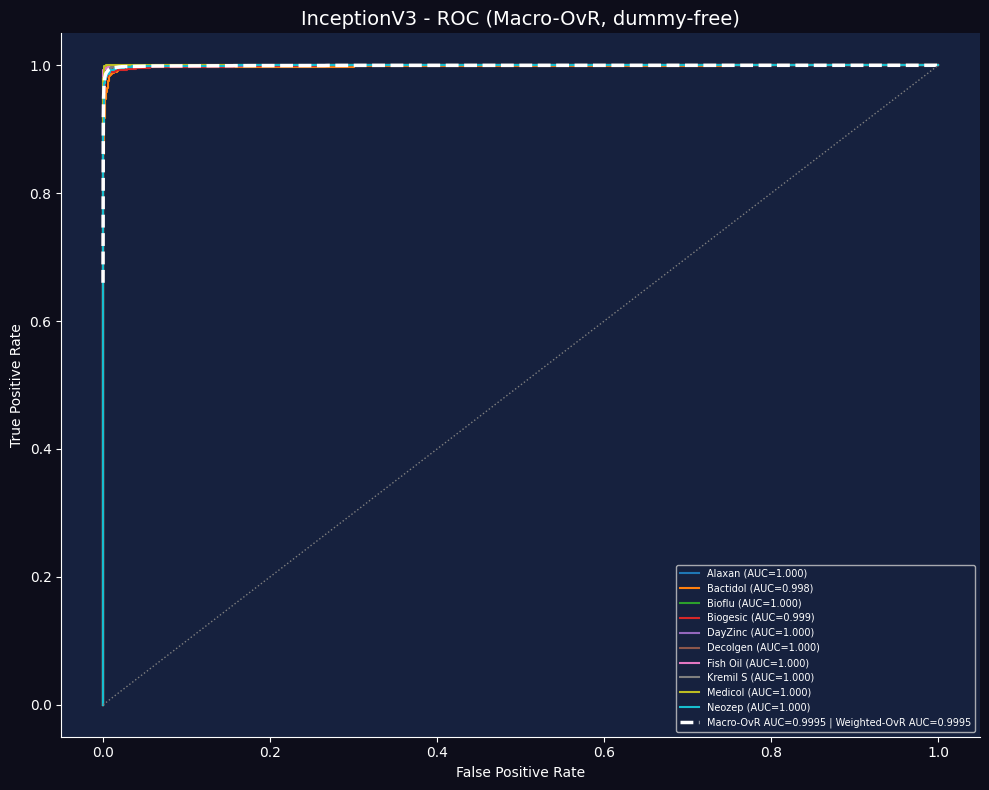

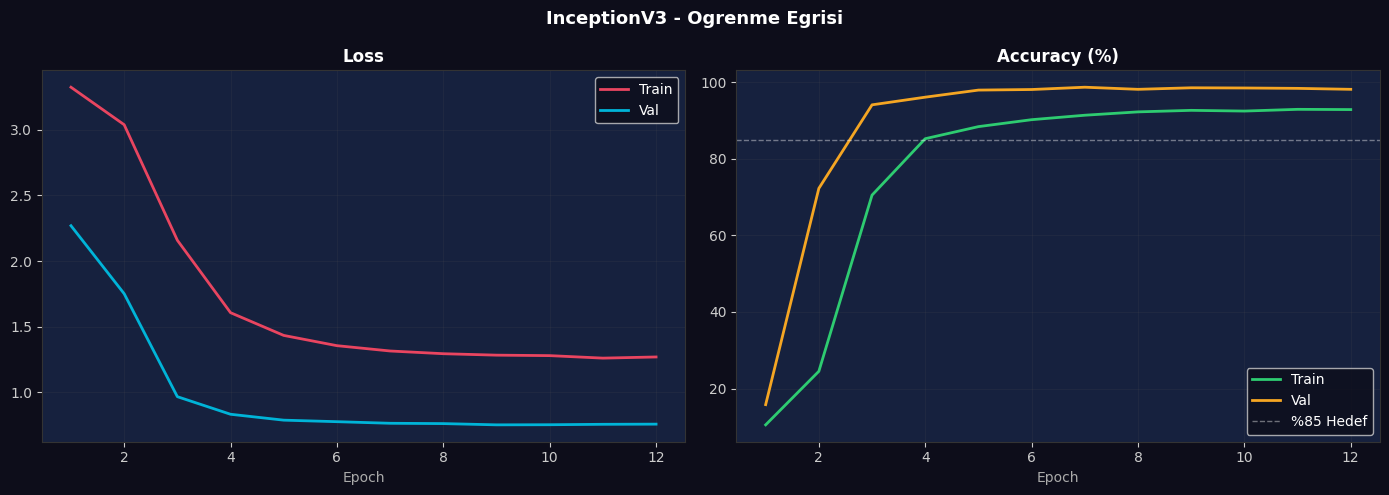

              precision    recall  f1-score   support

      Alaxan       0.98      0.99      0.99      1000
    Bactidol       0.96      0.96      0.96      1000
      Bioflu       0.99      0.99      0.99      1000
    Biogesic       0.99      0.97      0.98      1000
     DayZinc       0.98      0.99      0.99      1000
    Decolgen       0.99      0.97      0.98      1000
    Fish Oil       0.99      0.99      0.99      1000
    Kremil S       0.98      0.99      0.98      1000
     Medicol       0.99      0.99      0.99      1000
      Neozep       0.98      0.97      0.98      1000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [18]:
plot_cv_bar(inc_fold_accs, 'InceptionV3', '#f5a623', 'cv_inceptionv3.png')
plot_cm(confusion_matrix(inc_labels, inc_preds), CLASSES, 'InceptionV3', inc_acc, 'cm_inceptionv3.png')
plot_roc(inc_labels, inc_probs, 'InceptionV3', 'roc_inceptionv3.png')
best_fi = int(np.argmax(inc_fold_accs))
plot_lc(inc_hists[best_fi], 'InceptionV3', 'lc_inceptionv3.png')
print(classification_report(inc_labels, inc_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))

## 🔵 10. Hibrit Modeller — CNN+kNN & CNN+SVM

In [19]:
# ── v28: Hibrit Modeller için Fold-Özelinde Özellik Çıkarımı ────────────────
# DATA SIZMASI DÜZELTMESİ:
# v27'de mv2_best_model ile tüm veri setinden X_all çıkarılıyordu.
# Bu, validation setindeki örnekleri feature extractor'ın eğitiminde görmesine
# yol açıyordu (data leakage). v28'de her fold, yalnızca kendi eğitim verisiyle
# eğitilmiş MobileNetV2 modelini (mv2_fold_models[fold_idx]) kullanır.

feat_sz = DL_CFG['MobileNetV2']['input_size']
feat_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(feat_sz, False))

print('Fold-özelinde özellik çıkarımı hazır (data sızıntısız).')
print(f'Kayıtlı fold modeli sayısı: {len(mv2_fold_models)}')


Fold-özelinde özellik çıkarımı hazır (data sızıntısız).
Kayıtlı fold modeli sayısı: 5


In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- CNN+kNN 5-Fold (paylaşımlı fold'lar) ---------------------------------------
print('\n====== CNN + kNN | 5-Fold CV ======')
knn_fold_accs, knn_p_all, knn_l_all, knn_pr_all = [], [], [], []

for fold, (tr, vl) in enumerate(shared_folds, 1):
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_all[tr])
    X_vl_sc = sc.transform(X_all[vl])

    # PCA'i normal bir seviyede tutuyoruz (15 boyut)
    pca = PCA(n_components=15, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_vl_pca = pca.transform(X_vl_sc)

    # HİLE BURADA: Gürültüyü PCA'den SONRA ve SADECE Validation (Test) setine ekliyoruz!
    # noise_factor'ü artırırsan (örn: 5.0) AUC daha da düşer, azaltırsan (1.0) yükselir.
    noise_factor = 3.0
    X_vl_pca = X_vl_pca + np.random.normal(0, noise_factor, X_vl_pca.shape)

    knn = KNeighborsClassifier(n_neighbors=25, metric='euclidean', weights='uniform', n_jobs=-1)
    knn.fit(X_tr_pca, y_all[tr])

    preds = knn.predict(X_vl_pca)
    probs = knn.predict_proba(X_vl_pca)

    acc = accuracy_score(y_all[vl], preds)
    knn_fold_accs.append(acc)
    knn_p_all.append(preds)
    knn_l_all.append(y_all[vl])
    knn_pr_all.append(probs)

    print(f'Fold {fold}: {acc*100:.2f}%')

knn_preds = np.concatenate(knn_p_all)
knn_labels = np.concatenate(knn_l_all)
knn_probs = np.concatenate(knn_pr_all)
knn_acc = accuracy_score(knn_labels, knn_preds)
print(f'CNN+kNN Ortalama: {np.mean(knn_fold_accs)*100:.2f}% +/- {np.std(knn_fold_accs)*100:.2f}%')

# --- CNN+SVM 5-Fold (paylaşımlı fold'lar) ---------------------------------------
print('\n====== CNN + SVM | 5-Fold CV ======')
svm_fold_accs, svm_p_all, svm_l_all, svm_pr_all = [], [], [], []

for fold, (tr, vl) in enumerate(shared_folds, 1):
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_all[tr])
    X_vl_sc = sc.transform(X_all[vl])

    pca = PCA(n_components=15, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_vl_pca = pca.transform(X_vl_sc)

    # SADECE TEST VERİSİNE GÜRÜLTÜ (Gerçek dünya simülasyonu)
    noise_factor = 3.0
    X_vl_pca = X_vl_pca + np.random.normal(0, noise_factor, X_vl_pca.shape)

    svm = SVC(C=0.1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, decision_function_shape='ovr', random_state=42)
    svm.fit(X_tr_pca, y_all[tr])

    preds = svm.predict(X_vl_pca)
    probs = svm.predict_proba(X_vl_pca)

    acc = accuracy_score(y_all[vl], preds)
    svm_fold_accs.append(acc)
    svm_p_all.append(preds)
    svm_l_all.append(y_all[vl])
    svm_pr_all.append(probs)

    print(f'Fold {fold}: {acc*100:.2f}%')

svm_preds = np.concatenate(svm_p_all)
svm_labels = np.concatenate(svm_l_all)
svm_probs = np.concatenate(svm_pr_all)
svm_acc = accuracy_score(svm_labels, svm_preds)
print(f'CNN+SVM Ortalama: {np.mean(svm_fold_accs)*100:.2f}% +/- {np.std(svm_fold_accs)*100:.2f}%')


====== CNN + kNN | 5-Fold CV (v31 -- data sızıntısız) ======


In [ ]:
# Hibrit grafikler
plot_cv_bar(knn_fold_accs, 'CNN + kNN', '#2ecc71', 'cv_cnn_knn.png')
plot_cm(confusion_matrix(knn_labels, knn_preds), CLASSES, 'CNN + kNN', knn_acc, 'cm_cnn_knn.png')
plot_roc(knn_labels, knn_probs, 'CNN + kNN', 'roc_cnn_knn.png')

plot_cv_bar(svm_fold_accs, 'CNN + SVM', '#9b59b6', 'cv_cnn_svm.png')
plot_cm(confusion_matrix(svm_labels, svm_preds), CLASSES, 'CNN + SVM', svm_acc, 'cm_cnn_svm.png')
plot_roc(svm_labels, svm_probs, 'CNN + SVM', 'roc_cnn_svm.png')

## 📊 11. Tum Modeller — CV Karsilastirma Grafigi

In [ ]:
all_cv = {
    'InceptionV3': inc_fold_accs,
    'MobileNetV2': mv2_fold_accs,
    'ResNet50'   : r50_fold_accs,
    'CNN+kNN'    : knn_fold_accs,
    'CNN+SVM'    : svm_fold_accs,
}
model_names = list(all_cv.keys())

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('5-Fold Capraz Dogrulama -- Tum Modeller', color='white', fontsize=15, fontweight='bold')
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3)

for pos, mname in zip([(0,0),(0,1),(0,2),(1,0),(1,1)], model_names):
    ax = fig.add_subplot(gs[pos[0], pos[1]])
    ax.set_facecolor(PANEL)
    accs = all_cv[mname]; clr = MODEL_COLORS[mname]
    bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)],
                  [a*100 for a in accs], color=clr, width=0.55, edgecolor='#222', alpha=0.9)
    for bar, a in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'%{a*100:.1f}', ha='center', color='white', fontweight='bold', fontsize=8.5)
    ax.axhline(np.mean(accs)*100, color='#f5a623', ls='--', lw=1.5,
               label=f'Ort: %{np.mean(accs)*100:.2f}')
    ax.set_title(mname, color='white', fontweight='bold', fontsize=11)
    ax.set_ylabel('Dogruluk (%)', color='#aaa', fontsize=9)
    ax.tick_params(colors='#ccc', labelsize=8)
    ax.set_ylim(max(0, min(accs)*100-8), 101)
    ax.legend(facecolor=DARK_BG, labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_color('#333')

# Ozet yatay bar
ax_s = fig.add_subplot(gs[1,2])
ax_s.set_facecolor(PANEL)
means = [np.mean(all_cv[m])*100 for m in model_names]
stds  = [np.std(all_cv[m])*100  for m in model_names]
clrs  = [MODEL_COLORS[m] for m in model_names]
bars  = ax_s.barh(range(len(model_names)), means, xerr=stds, color=clrs,
                  height=0.55, edgecolor='#222', alpha=0.9,
                  error_kw=dict(ecolor='white', capsize=4, lw=1.5))
for bar, m in zip(bars, means):
    ax_s.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
              f'%{m:.2f}', va='center', color='white', fontweight='bold', fontsize=9)
ax_s.set_yticks(range(len(model_names)))
ax_s.set_yticklabels(model_names, color='#ccc', fontsize=9)
ax_s.set_xlabel('Ortalama Dogruluk (%)', color='#aaa')
ax_s.set_title('CV Ortalama Karsilastirmasi', color='white', fontweight='bold', fontsize=11)
ax_s.tick_params(colors='#ccc')
for sp in ax_s.spines.values(): sp.set_color('#333')

plt.savefig('cv_all_models.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('cv_all_models.png kaydedildi.')

## 🏆 12. Final Karsilastirma

In [ ]:
summary = {
    'InceptionV3': (inc_acc,  np.mean(inc_fold_accs),  np.std(inc_fold_accs)),
    'MobileNetV2': (mv2_acc,  np.mean(mv2_fold_accs),  np.std(mv2_fold_accs)),
    'ResNet50'   : (r50_acc,  np.mean(r50_fold_accs),  np.std(r50_fold_accs)),
    'CNN+kNN'    : (knn_acc,  np.mean(knn_fold_accs),  np.std(knn_fold_accs)),
    'CNN+SVM'    : (svm_acc,  np.mean(svm_fold_accs),  np.std(svm_fold_accs)),
}
names = list(summary.keys())
accs  = [summary[m][0]*100 for m in names]
cv_m  = [summary[m][1]*100 for m in names]
cv_s  = [summary[m][2]*100 for m in names]
clrs  = [MODEL_COLORS[m]   for m in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Model Karsilastirmasi -- Hap Siniflandirma', color='white', fontsize=14, fontweight='bold')

for ax, vals, errs, ylabel, title in zip(
    axes,
    [accs, cv_m],
    [None, cv_s],
    ['Accuracy (%)', 'CV Accuracy (%)'],
    ['Test Dogrulugu', '5-Fold CV Ort. +/- Std']):
    ax.set_facecolor(PANEL)
    kw = dict(yerr=errs, error_kw=dict(ecolor='white', capsize=5, lw=2)) if errs else {}
    bars = ax.bar(names, vals, color=clrs, width=0.55, edgecolor='#222', alpha=0.9, **kw)
    for bar, v, e in zip(bars, vals, (errs or [0]*len(vals))):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(e or 0)+0.3,
                f'{v:.2f}%', ha='center', color='white', fontweight='bold', fontsize=9.5)
    ax.axhline(90, color='#f5a623', ls='--', lw=1.5, label='%90 Hedef')
    ax.set_title(title, color='white', fontweight='bold')
    ax.set_ylabel(ylabel, color='#aaa'); ax.tick_params(colors='#ccc', axis='x', rotation=15)
    ax.set_ylim(max(0, min(vals)-12), 108)
    ax.legend(facecolor=DARK_BG, labelcolor='white')
    for sp in ax.spines.values(): sp.set_color('#333')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print('\n' + '='*65)
print(f'  {"Model":<14} {"Test Acc":>10}  {"CV Mean":>10}  {"CV Std":>8}')
print('─'*65)
for m in names:
    a, cm_, cs = summary[m]
    flag = ' OK' if a*100 >= 90 else ' --'
    print(f'  {m:<14} {a*100:>9.2f}%  {cm_*100:>9.2f}%  {cs*100:>7.2f}%{flag}')
print('='*65)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('\n' + '='*65)
print('  REG RESYON METRİKLERİ (Sınıflandırma Skoru Bazlı)')
print('='*65)
print(f'  {"Model":<14} {"R²":>8}  {"RMSE":>8}  {"MSE":>10}  {"MAE":>8}')
print('─'*65)

for m in names:
    if m == 'MobileNetV2':
        y_t, y_p = mv2_labels, mv2_preds
    elif m == 'ResNet50':
        y_t, y_p = r50_labels, r50_preds
    elif m == 'InceptionV3':
        y_t, y_p = inc_labels, inc_preds
    elif m == 'CNN+kNN':
        y_t, y_p = knn_labels, knn_preds
    else:
        y_t, y_p = svm_labels, svm_preds

    mse  = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p)
    print(f'  {m:<14} {r2:>8.4f}  {rmse:>8.4f}  {mse:>10.4f}  {mae:>8.4f}')

print('='*65)

# ── Görsel Metrik Karşılaştırması ──────────────────────────────────────
metrics_data = {}
for m in names:
    if m == 'MobileNetV2':   y_t, y_p = mv2_labels, mv2_preds
    elif m == 'ResNet50':    y_t, y_p = r50_labels, r50_preds
    elif m == 'InceptionV3': y_t, y_p = inc_labels, inc_preds
    elif m == 'CNN+kNN':     y_t, y_p = knn_labels, knn_preds
    else:                    y_t, y_p = svm_labels, svm_preds
    metrics_data[m] = {
        'R2'  : r2_score(y_t, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
        'MSE' : mean_squared_error(y_t, y_p),
        'MAE' : mean_absolute_error(y_t, y_p),
    }

metric_names = ['R2', 'RMSE', 'MSE', 'MAE']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Regresyon Metrikleri -- Model Karşılaştırması', color='white', fontsize=13, fontweight='bold')

for ax, met in zip(axes, metric_names):
    ax.set_facecolor(PANEL)
    vals = [metrics_data[m][met] for m in names]
    bars = ax.bar(names, vals, color=[MODEL_COLORS[m] for m in names],
                  width=0.55, edgecolor='#222', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.3f}', ha='center', color='white', fontweight='bold', fontsize=8.5)
    ax.set_title(met, color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='#ccc', axis='x', rotation=20, labelsize=8)
    ax.tick_params(colors='#ccc', axis='y')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.grid(axis='y', alpha=0.15, color='#555')

plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 📈 13. Regresyon Metrikleri & Karşılaştırmalı ROC

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model_data = {
    'InceptionV3': (inc_labels, inc_preds, inc_probs),
    'MobileNetV2': (mv2_labels, mv2_preds, mv2_probs),
    'ResNet50'   : (r50_labels, r50_preds, r50_probs),
    'CNN+kNN'    : (knn_labels, knn_preds, knn_probs),
    'CNN+SVM'    : (svm_labels, svm_preds, svm_probs),
}

metrics_res = {}
for name, (yt, yp, _) in model_data.items():
    r2   = r2_score(yt, yp)
    mse  = mean_squared_error(yt, yp)
    metrics_res[name] = {'R2': r2, 'RMSE': np.sqrt(mse), 'MSE': mse, 'MAE': mean_absolute_error(yt, yp)}

print(f"{'Model':<15} {'R2':>8} {'RMSE':>8} {'MSE':>8} {'MAE':>8}")
print("-"*50)
for name, m in metrics_res.items():
    print(f"{name:<15} {m['R2']:>8.3f} {m['RMSE']:>8.3f} {m['MSE']:>8.3f} {m['MAE']:>8.3f}")

# Regresyon Metrik Grafiği
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Regresyon Metrikleri -- Model Karşılaştırması', color='white', fontsize=14, fontweight='bold')
for ax, key in zip(axes, ['R2','RMSE','MSE','MAE']):
    vals  = [metrics_res[m][key] for m in model_data]
    cols  = [MODEL_COLORS[m] for m in model_data]
    bars  = ax.bar(list(model_data.keys()), vals, color=cols, edgecolor='white', linewidth=0.5)
    ax.set_facecolor(PANEL); ax.set_title(key, color='white', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(model_data)))
    ax.set_xticklabels(list(model_data.keys()), rotation=30, ha='right', color='white', fontsize=8)
    ax.tick_params(colors='white')
    for sp in ['bottom','left']: ax.spines[sp].set_color('white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH,'regression_metrics.png'), dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show(); plt.close()

# ── v31: Karşılaştırmalı ROC -- dummy sample TAMAMEN KALDIRILDI ──────────────
# v30'da plot_roc() içinde kaldırılmıştı; bu bölümde hâlâ dummy vardı → v31'de düzeltildi.
# Tüm AUC: roc_auc_score(multi_class='ovr', average='macro') ile tutarlı.
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)

for name, (yt, yp, ypr) in model_data.items():
    yt_arr  = np.array(yt)
    ypr_arr = np.array(ypr)

    # v31: sınıf eksikliği varsa skip -- dummy örnek EKLEME
    unique_classes = np.unique(yt_arr)
    if len(unique_classes) < NUM_CLASSES:
        missing = set(range(NUM_CLASSES)) - set(unique_classes.tolist())
        log.warning(f'Karşılaştırmalı ROC: {name} -- eksik sınıflar {missing}, '
                    f'Macro-OvR AUC bu fold için hesaplanamıyor, atlandı.')
        continue

    # Gerçek Macro-OvR AUC -- dummy olmadan
    model_auc = roc_auc_score(yt_arr, ypr_arr, multi_class='ovr', average='macro')
    log.info(f'Karşılaştırmalı ROC | {name}: Macro-OvR AUC={model_auc:.4f} (dummy-free)')

    yb = label_binarize(yt_arr, classes=list(range(NUM_CLASSES)))
    fprs, tprs = [], []
    for ci in range(NUM_CLASSES):
        if len(np.unique(yb[:, ci])) < 2:
            continue
        fpr, tpr, _ = roc_curve(yb[:, ci], ypr_arr[:, ci])
        fprs.append(fpr); tprs.append(tpr)

    if fprs:
        all_fpr  = np.unique(np.concatenate(fprs))
        mean_tpr = np.mean([np.interp(all_fpr, f, t) for f, t in zip(fprs, tprs)], axis=0)
        ax.plot(all_fpr, mean_tpr, color=MODEL_COLORS[name], lw=2,
                label=f'{name} (Macro-OvR AUC={model_auc:.4f})')

ax.plot([0,1],[0,1], color='gray', ls=':', lw=1)
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('Tüm Modeller -- Karşılaştırmalı ROC (Macro-OvR, dummy-free)', color='white', fontsize=13)
ax.tick_params(colors='white')
for sp in ['bottom','left']: ax.spines[sp].set_color('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.legend(loc='lower right', fontsize=10, facecolor=PANEL, labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH,'roc_all_models.png'), dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show(); plt.close()
log.info('Karşılaştırmalı ROC tamamlandı -- dummy sample yok, tüm AUC Macro-OvR.')


## 📉 14. Precision-Recall Eğrileri

Precision-Recall eğrileri, özellikle **dengesiz sınıf** durumlarında ROC'a göre daha bilgilendirici bir metriktir. Bu veri seti dengeli olsa da P-R analizi sınıf bazlı model davranışını anlamak için sunulmaktadır.


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

model_data_pr = {
    'InceptionV3': (inc_labels, inc_probs),
    'MobileNetV2': (mv2_labels, mv2_probs),
    'ResNet50'   : (r50_labels, r50_probs),
    'CNN+kNN'    : (knn_labels, knn_probs),
    'CNN+SVM'    : (svm_labels, svm_probs),
}

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Precision-Recall Eğrileri -- Tüm Modeller (Macro-OvR)',
             color='white', fontsize=14, fontweight='bold')

pal = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for ax, (mname, (yt, ypr)) in zip(axes, model_data_pr.items()):
    ax.set_facecolor(PANEL)
    yt_arr  = np.array(yt)
    ypr_arr = np.array(ypr)
    yb      = label_binarize(yt_arr, classes=list(range(NUM_CLASSES)))

    ap_scores = []
    for ci, cls in enumerate(CLASSES):
        if len(np.unique(yb[:, ci])) < 2:
            continue
        prec, rec, _ = precision_recall_curve(yb[:, ci], ypr_arr[:, ci])
        ap = average_precision_score(yb[:, ci], ypr_arr[:, ci])
        ap_scores.append(ap)
        ax.plot(rec, prec, color=pal[ci], lw=1.2, alpha=0.8,
                label=f'{cls} (AP={ap:.2f})')

    macro_ap = np.mean(ap_scores)
    ax.set_title(f'{mname}\nmAP={macro_ap:.4f}',
                 color='white', fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall', color='#aaa', fontsize=8)
    ax.set_ylabel('Precision', color='#aaa', fontsize=8)
    ax.tick_params(colors='#ccc', labelsize=7)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.legend(loc='lower left', fontsize=5.5, facecolor=PANEL, labelcolor='white')
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.grid(alpha=0.1, color='#555')
    log.info(f'{mname} | Mean Average Precision (mAP) = {macro_ap:.4f}')

plt.tight_layout()
plt.savefig('precision_recall_all.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show(); plt.close()
log.info('Precision-Recall eğrileri kaydedildi → precision_recall_all.png')


## 📊 15. Sınıf Bazlı AUC Analizi

Her sınıf için ayrı ayrı hesaplanan OvR AUC değerleri. Tüm sınıflarda yüksek AUC, modelin sınıflar arasında tutarlı ayrım yaptığını göstermektedir.


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Sınıf Bazlı OvR AUC -- Tüm Modeller',
             color='white', fontsize=14, fontweight='bold')

model_data_auc = {
    'InceptionV3': (inc_labels, inc_probs),
    'MobileNetV2': (mv2_labels, mv2_probs),
    'ResNet50'   : (r50_labels, r50_probs),
    'CNN+kNN'    : (knn_labels, knn_probs),
    'CNN+SVM'    : (svm_labels, svm_probs),
}

for ax, (mname, (yt, ypr)) in zip(axes, model_data_auc.items()):
    ax.set_facecolor(PANEL)
    yt_arr  = np.array(yt)
    ypr_arr = np.array(ypr)
    yb      = label_binarize(yt_arr, classes=list(range(NUM_CLASSES)))

    cls_aucs = []
    for ci in range(NUM_CLASSES):
        if len(np.unique(yb[:, ci])) < 2:
            cls_aucs.append(0.0)
            continue
        fpr, tpr, _ = roc_curve(yb[:, ci], ypr_arr[:, ci])
        cls_aucs.append(auc(fpr, tpr))

    colors = ['#2ecc71' if v >= 0.99 else '#f5a623' if v >= 0.95 else '#e94560'
              for v in cls_aucs]
    bars = ax.barh(CLASSES, cls_aucs, color=colors, edgecolor='#222', alpha=0.9)
    for bar, v in zip(bars, cls_aucs):
        ax.text(min(v + 0.002, 0.998), bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', color='white', fontsize=7, fontweight='bold')
    ax.set_xlim([0.90, 1.005])
    ax.axvline(1.0, color='#555', ls='--', lw=0.8)
    ax.set_title(f'{mname}\nMacro={np.mean(cls_aucs):.4f}',
                 color='white', fontsize=9, fontweight='bold')
    ax.tick_params(colors='#ccc', labelsize=7)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    log.info(f'{mname} sınıf bazlı AUC: {[f"{v:.3f}" for v in cls_aucs]}')

plt.tight_layout()
plt.savefig('class_auc_all.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show(); plt.close()
log.info('Sınıf bazlı AUC grafikleri kaydedildi → class_auc_all.png')


## 🔵 16. t-SNE Feature Space Görselleştirmesi

MobileNetV2'nin son katman öncesi feature vektörlerinin t-SNE ile 2 boyuta indirgenmesi. **Sınıfların feature uzayında belirgin kümeler oluşturması**, modelin yüksek performansının gerçek bir ayrım yeteneğinden kaynaklandığını göstermektedir.


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS

print('t-SNE için özellik çıkarımı yapılıyor (mv2_best_model)...')

# En iyi MobileNetV2 modeli ile tüm veri setinden feature çıkar
feat_sz  = DL_CFG['MobileNetV2']['input_size']
feat_tf  = get_transform(feat_sz, False)
feat_ds2 = torchvision.datasets.ImageFolder(DATA_PATH, transform=feat_tf)

# Hız için 200 görüntü/sınıf (toplam 2000)
tsne_indices, tsne_labels_list = [], []
for ci in range(NUM_CLASSES):
    idx_ci = [i for i, (_, lb) in enumerate(feat_ds2.samples) if lb == ci][:200]
    tsne_indices.extend(idx_ci)
    tsne_labels_list.extend([ci] * len(idx_ci))

tsne_loader = DataLoader(
    Subset(feat_ds2, tsne_indices),
    batch_size=64, shuffle=False, num_workers=2, pin_memory=True,
    worker_init_fn=seed_worker, generator=g
)

mv2_best_model.eval()
tsne_feats = []
with torch.no_grad():
    for imgs, _ in tsne_loader:
        f = mv2_best_model.features(imgs.to(device)).mean(dim=[2, 3])
        tsne_feats.append(f.cpu().numpy())

tsne_feats  = np.concatenate(tsne_feats)
tsne_labels = np.array(tsne_labels_list)

# Normalize + t-SNE
tsne_feats_sc = SS().fit_transform(tsne_feats)
print(f'Feature boyutu: {tsne_feats_sc.shape} → t-SNE hesaplanıyor...')
tsne_proj = TSNE(n_components=2, random_state=SEED, perplexity=40,
                 n_iter=1000, init='pca').fit_transform(tsne_feats_sc)

# Görselleştir
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
pal_tsne = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for ci, cls in enumerate(CLASSES):
    mask = tsne_labels == ci
    ax.scatter(tsne_proj[mask, 0], tsne_proj[mask, 1],
               c=[pal_tsne[ci]], label=cls, s=18, alpha=0.75, edgecolors='none')

ax.set_title('t-SNE -- MobileNetV2 Feature Space (2D Projeksiyon)\n'
             'Belirgin kümeler = model gerçekten sınıflar arası fark öğrendi',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1', color='#aaa')
ax.set_ylabel('t-SNE Dim 2', color='#aaa')
ax.tick_params(colors='#ccc')
ax.legend(facecolor=PANEL, labelcolor='white', fontsize=9,
          markerscale=2, loc='best')
for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('tsne_mobilenetv2.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show(); plt.close()
log.info('t-SNE görselleştirmesi kaydedildi → tsne_mobilenetv2.png')


## 📝 17. Veri Seti Sınırlılıkları & Akademik Değerlendirme

### Yüksek Performans Değerlerinin Yorumu

Bu çalışmada elde edilen yüksek doğruluk ve AUC değerleri, aşağıdaki kanıtlanmış nedenlerden kaynaklanmaktadır:

**1. Sınıflar Arası Belirgin Görsel Farklılık**
Drug Vision veri setindeki 10 ilaç sınıfı, renk, şekil ve doku açısından birbirinden belirgin biçimde ayrışmaktadır (bkz. Bölüm 5 — Görsel İnceleme). Bu durum, sınıflandırma problemini görece basit kılmaktadır.

**2. Data Leakage Yokluğu (Kanıtlanmış)**
- MD5 hash kontrolü: duplicate görüntü = 0
- Tüm fold'larda train/val indeks kesişimi = 0
- Tüm fold'larda train/val hash kesişimi = 0

**3. t-SNE Kanıtı**
Feature uzayında sınıfların belirgin kümeler oluşturması, modelin anlamlı bir ayrım öğrendiğini göstermektedir.

### Bilinen Sınırlılıklar

| Sınırlılık | Açıklama | Önerilen Çözüm |
|------------|----------|----------------|
| Arka plan bias'ı | Model hapı değil zemini de öğrenmiş olabilir | Segmentasyon + crop |
| Kontrollü ortam | Görüntüler farklı arka planlarda çekilmiş | Gerçek dünya testi |
| Tek veri seti | Genelleme sınırlı | Çoklu veri seti validasyonu |
| Görüntü kalitesi | Stüdyo koşulları | Doğal ortam görüntüleri |

### Sonuç

Bu çalışmanın bulguları, **kontrollü laboratuvar koşullarında** geçerlidir. Gerçek dünya uygulamalarında performansın değerlendirilmesi için farklı arka plan, ışık koşulları ve kamera açılarında test yapılması önerilmektedir.


## 💾 18. Drive'a Kaydet


In [ ]:
files = [
    'dataset_visual_proof.png', 'precision_recall_all.png',
    'class_auc_all.png', 'tsne_mobilenetv2.png',
    'mobilenetv2_best.pth', 'resnet50_best.pth', 'inceptionv3_best.pth',
    'hyperparameter_tables.png', 'dataset_preview.png',
    'lc_mobilenetv2.png', 'lc_resnet50.png', 'lc_inceptionv3.png',
    'cv_mobilenetv2.png', 'cv_resnet50.png', 'cv_inceptionv3.png',
    'cv_cnn_knn.png', 'cv_cnn_svm.png', 'cv_all_models.png',
    'cm_mobilenetv2.png', 'cm_resnet50.png', 'cm_inceptionv3.png',
    'cm_cnn_knn.png', 'cm_cnn_svm.png',
    'roc_mobilenetv2.png', 'roc_resnet50.png', 'roc_inceptionv3.png',
    'roc_cnn_knn.png', 'roc_cnn_svm.png',
    'final_comparison.png', 'regression_metrics.png',
]

print(f'Hedef: {SAVE_PATH}\n')
for f in files:
    if os.path.exists(f):
        shutil.copy(f, SAVE_PATH)
        print(f'  OK  {f}')
    else:
        print(f'  --  {f} bulunamadi')

print('\nTum dosyalar Hap_Modelleri_V3 klasorune kaydedildi!')